# Construction of an Arbitrage-Free Local-Volatility Surface from Option Quotes

### From market prices to Dupire's equation, and from Dupire's equation to exotic prices

**Ahmed Bounadar**

---

This notebook builds, end to end, the object that sits underneath most equity-derivatives
desks: the *local-volatility surface*. The pipeline is

$$
\underbrace{\{C^{\text{mid}}(K_i,T_j)\}}_{\text{quotes}}
\;\longrightarrow\;
\underbrace{\sigma_{\mathrm{BS}}(K_i,T_j)}_{\text{inversion}}
\;\longrightarrow\;
\underbrace{w(y,T)}_{\substack{\text{arbitrage-free}\\\text{interpolation}}}
\;\longrightarrow\;
\underbrace{\sigma_{\mathrm{loc}}(K,T)}_{\text{Dupire}}
\;\longrightarrow\;
\underbrace{\text{exotics}}_{\text{Monte Carlo}}
$$

The mathematically interesting step is the third arrow. Dupire's formula requires
$\partial_T C$, $\partial_K C$ and $\partial^2_{KK}C$, but $C$ is only observed on a coarse
grid and only up to a bid--ask spread. Numerical differentiation of noisy data is an
**ill-posed inverse problem**: the second difference amplifies quoting noise by $h^{-2}$.
Section 8 quantifies this exactly and shows that no choice of stencil fixes it — the cure is
*regularisation*, which here takes the form of projecting the data onto a family of surfaces
that is arbitrage-free by construction.

**Contents**

| § | Content |
|---|---|
| 1 | Black--Scholes, Greeks, implied-volatility inversion |
| 2 | The data-generating process (Heston) and a Fourier pricer |
| 3 | A synthetic market with realistic microstructure noise |
| 4 | SVI, SSVI, eSSVI and the static-arbitrage conditions |
| 5 | Maturity interpolation that preserves calendar monotonicity |
| 6 | Dupire's equation in both of its forms |
| 7 | Monte Carlo engines (local vol, Heston QE, Black--Scholes) |
| 8 | The ill-posedness of naive differentiation |
| 9 | Extraction of the local-volatility surface and validation against ground truth |
| 10 | Dupire consistency: repricing the vanillas |
| 11 | Exotics and model risk |
| 12 | How much of the surface is really determined by the data? |


## 1. Black--Scholes, Greeks and implied-volatility inversion

Under the risk-neutral measure $\mathbb{Q}$, with constant rate $r$ and dividend yield $q$,
$dS_t = (r-q)S_t\,dt + \sigma S_t\,dW_t$ gives

$$C^{\mathrm{BS}}(S,K,T,\sigma)=Se^{-qT}\mathcal N(d_+)-Ke^{-rT}\mathcal N(d_-),\qquad
d_\pm=\frac{\log(S/K)+(r-q\pm\tfrac12\sigma^2)T}{\sigma\sqrt T}.$$

**Proposition (well-posedness of the inversion).** *For a quote $C$ strictly inside the
static no-arbitrage bounds $\big(e^{-rT}(F-K)^+,\,Se^{-qT}\big)$, there exists a unique
$\sigma>0$ with $C^{\mathrm{BS}}(\sigma)=C$.*

*Proof.* The vega
$\partial_\sigma C^{\mathrm{BS}} = Se^{-qT}\sqrt{T}\,\varphi(d_+)>0$ for every $\sigma>0$, so
$\sigma\mapsto C^{\mathrm{BS}}(\sigma)$ is continuous and strictly increasing; its limits are
$e^{-rT}(F-K)^+$ as $\sigma\downarrow0$ and $Se^{-qT}$ as $\sigma\uparrow\infty$. The
intermediate value theorem and strict monotonicity give existence and uniqueness. $\blacksquare$

Uniqueness is what makes the implied volatility a legitimate *change of variable* rather
than a model assumption. Note that vega vanishes exponentially as $|d_+|\to\infty$: deep in
the wings the map is badly conditioned, which is the first place where market noise is
magnified. We use a damped Newton iteration seeded by the Brenner--Subrahmanyam (1988)
approximation $\sigma\approx\sqrt{2\pi/T}\,C/S$, with a Brent bisection fallback.

In [1]:
"""Black--Scholes pricing, Greeks, and implied-volatility inversion."""
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq

SQRT2PI = np.sqrt(2.0 * np.pi)


def bs_d1d2(S, K, T, r, q, sigma):
    """d1, d2 of the Black--Scholes formula (vectorised, sigma*sqrt(T) > 0)."""
    S, K, T, sigma = map(np.asarray, (S, K, T, sigma))
    vsqrt = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / vsqrt
    return d1, d1 - vsqrt


def bs_price(S, K, T, r, q, sigma, kind="c"):
    """European vanilla price under Black--Scholes with continuous dividend yield q."""
    S, K, T, sigma = np.broadcast_arrays(*map(np.asarray, (S, K, T, sigma)))
    out = np.zeros_like(S, dtype=float)
    live = (T > 0) & (sigma > 0)
    d1, d2 = bs_d1d2(S[live], K[live], T[live], r, q, sigma[live])
    df_r, df_q = np.exp(-r * T[live]), np.exp(-q * T[live])
    if kind == "c":
        out[live] = S[live] * df_q * norm.cdf(d1) - K[live] * df_r * norm.cdf(d2)
        out[~live] = np.maximum(S[~live] - K[~live], 0.0)
    else:
        out[live] = K[live] * df_r * norm.cdf(-d2) - S[live] * df_q * norm.cdf(-d1)
        out[~live] = np.maximum(K[~live] - S[~live], 0.0)
    return out if out.ndim else float(out)


def bs_vega(S, K, T, r, q, sigma):
    """dPrice/dsigma. Identical for calls and puts."""
    d1, _ = bs_d1d2(S, K, T, r, q, sigma)
    return S * np.exp(-q * T) * np.sqrt(T) * np.exp(-0.5 * d1 ** 2) / SQRT2PI


def implied_vol(price, S, K, T, r, q, kind="c", tol=1e-12, lo=1e-6, hi=5.0):
    """Invert Black--Scholes for sigma.

    Strategy: a safeguarded Newton iteration seeded with the Brenner--Subrahmanyam
    ATM approximation, with a Brent bisection fallback.  Returns NaN when the quote
    violates the static no-arbitrage bounds, in which case no sigma can exist.
    """
    df_r, df_q = np.exp(-r * T), np.exp(-q * T)
    F = S * df_q / df_r
    intrinsic = df_r * (max(F - K, 0.0) if kind == "c" else max(K - F, 0.0))
    upper = df_q * S if kind == "c" else df_r * K
    if not (intrinsic - 1e-14 < price < upper):
        return np.nan

    # Brenner--Subrahmanyam (1988) seed, exact at the money.
    sigma = max(np.sqrt(2.0 * np.pi / T) * price / S, 1e-3)
    for _ in range(60):
        diff = bs_price(S, K, T, r, q, sigma, kind) - price
        v = bs_vega(S, K, T, r, q, sigma)
        if abs(diff) < tol:
            return float(sigma)
        if v < 1e-12:
            break
        step = diff / v
        step = np.clip(step, -0.5, 0.5)            # damped Newton
        sigma_new = sigma - step
        if not (lo < sigma_new < hi):
            break
        sigma = sigma_new
    try:
        f = lambda s: bs_price(S, K, T, r, q, s, kind) - price
        return float(brentq(f, lo, hi, xtol=1e-14, maxiter=300))
    except ValueError:
        return np.nan


implied_vol_vec = np.vectorize(implied_vol, excluded={"kind"})


## 2. The data-generating process

A real quote file cannot be shipped inside a notebook, so we manufacture one — and this turns
out to be an advantage rather than a compromise: because we know the process that generated
the prices, we can compute the **true** local-volatility surface and score our estimator
against it. Under Heston (1993),

$$dS_t=(r-q)S_t\,dt+\sqrt{v_t}\,S_t\,dW^1_t,\qquad
dv_t=\kappa(\theta-v_t)\,dt+\xi\sqrt{v_t}\,dW^2_t,\qquad d\langle W^1,W^2\rangle_t=\rho\,dt .$$

Prices come from the COS method of Fang & Oosterlee (2008): the risk-neutral density is
expanded on a cosine basis over a truncated interval $[a,b]$,
$f(y)\approx\frac{2}{b-a}\sum_{k}{}^{\prime}\,
\mathrm{Re}\!\left\{\phi\!\left(\tfrac{k\pi}{b-a}\right)e^{-ik\pi a/(b-a)}\right\}
\cos\!\left(k\pi\tfrac{y-a}{b-a}\right)$, and the payoff coefficients are analytic. Convergence
is exponential in the number of terms for smooth densities. We use the "little Heston trap"
form of the characteristic function (Albrecher et al., 2007), which keeps the complex
logarithm on the principal branch.

We price puts and recover calls by parity, since the put payoff coefficients are numerically
benign. The implementation is cross-checked below against an independent Lewis-type contour
integral.

In [2]:
"""Heston (1993) model: characteristic function and Fang--Oosterlee COS pricer.

This plays the role of the *unobservable data-generating process*.  We never use
it in the calibration: it only produces the synthetic quotes and, later, the
ground-truth local-volatility surface against which our estimator is scored.
"""
import numpy as np
from dataclasses import dataclass


@dataclass
class HestonParams:
    v0: float      # initial variance
    kappa: float   # mean-reversion speed
    theta: float   # long-run variance
    sigma: float   # vol-of-vol
    rho: float     # spot/vol correlation

    def feller(self):
        """Feller ratio 2*kappa*theta/sigma**2; > 1 keeps the variance strictly positive."""
        return 2.0 * self.kappa * self.theta / self.sigma ** 2


def heston_cf(u, T, r, q, p: HestonParams):
    """Characteristic function of log(S_T/S_0) in the 'little Heston trap' form
    of Albrecher et al. (2007), which is continuous across the branch cut."""
    u = np.asarray(u, dtype=complex)
    kappa, theta, sig, rho, v0 = p.kappa, p.theta, p.sigma, p.rho, p.v0
    xi = kappa - sig * rho * 1j * u
    d = np.sqrt(xi ** 2 + (sig ** 2) * (1j * u + u ** 2))
    g = (xi - d) / (xi + d)                       # trap-free branch
    e = np.exp(-d * T)
    C = (kappa * theta / sig ** 2) * ((xi - d) * T - 2.0 * np.log((1.0 - g * e) / (1.0 - g)))
    D = ((xi - d) / sig ** 2) * (1.0 - e) / (1.0 - g * e)
    return np.exp(1j * u * (r - q) * T + C + D * v0)


def _cos_coeffs(a, b, N):
    k = np.arange(N)
    return k, k * np.pi / (b - a)


def _chi_psi(a, b, c, d, N):
    k = np.arange(N)
    kp = k * np.pi / (b - a)
    cc, dd = (c - a) * kp, (d - a) * kp
    chi = (np.cos(dd) * np.exp(d) - np.cos(cc) * np.exp(c)
           + kp * np.sin(dd) * np.exp(d) - kp * np.sin(cc) * np.exp(c)) / (1.0 + kp ** 2)
    psi = np.empty(N)
    psi[0] = d - c
    psi[1:] = (np.sin(dd[1:]) - np.sin(cc[1:])) / kp[1:]
    return chi, psi


def heston_cumulants(T, r, q, p: HestonParams):
    """First two cumulants of log(S_T/S_0) (Fang & Oosterlee 2008, Table 11)."""
    kappa, theta, sig, rho, v0 = p.kappa, p.theta, p.sigma, p.rho, p.v0
    e = np.exp(-kappa * T)
    c1 = (r - q) * T + (1.0 - e) * (theta - v0) / (2.0 * kappa) - 0.5 * theta * T
    c2 = (1.0 / (8.0 * kappa ** 3)) * (
        sig * T * kappa * e * (v0 - theta) * (8.0 * kappa * rho - 4.0 * sig)
        + kappa * rho * sig * (1.0 - e) * (16.0 * theta - 8.0 * v0)
        + 2.0 * theta * kappa * T * (-4.0 * kappa * rho * sig + sig ** 2 + 4.0 * kappa ** 2)
        + sig ** 2 * ((theta - 2.0 * v0) * np.exp(-2.0 * kappa * T)
                      + theta * (6.0 * e - 7.0) + 2.0 * v0)
        + 8.0 * kappa ** 2 * (v0 - theta) * (1.0 - e))
    return c1, abs(c2)


def heston_price(S0, K, T, r, q, p: HestonParams, kind="c", N=4096, L=14.0):
    """European vanilla by the COS method.  We always price the *put* (whose
    payoff coefficients are numerically benign) and recover the call by parity."""
    K = np.atleast_1d(np.asarray(K, dtype=float))
    c1, c2 = heston_cumulants(T, r, q, p)
    a, b = c1 - L * np.sqrt(c2), c1 + L * np.sqrt(c2)
    x = np.log(S0 / K)                             # log-moneyness of the quote

    chi, psi = _chi_psi(a, b, a, 0.0, N)
    U = 2.0 / (b - a) * (-chi + psi)               # put payoff cosine coefficients
    k = np.arange(N)
    u = k * np.pi / (b - a)
    cf = heston_cf(u, T, r, q, p)
    cfU = cf * U
    cfU[0] *= 0.5                                  # primed summation

    # Processed in blocks of strikes: the (N x n_K) array is the memory bottleneck.
    price_put = np.empty(x.size)
    BLK = 64
    for i0 in range(0, x.size, BLK):
        xb = x[i0:i0 + BLK]
        arg = np.exp(1j * np.outer(u, (xb - a)))
        price_put[i0:i0 + BLK] = np.real(cfU[:, None] * arg).sum(axis=0)
    price_put *= K * np.exp(-r * T)
    if kind == "p":
        out = price_put
    else:
        out = price_put + S0 * np.exp(-q * T) - K * np.exp(-r * T)
    return out if out.size > 1 else float(out[0])


## 3. A synthetic market with microstructure noise

Three noise sources are superimposed on the exact prices, because those are the three that
actually destroy the differentiation step:

1. a **bid--ask spread**, so only a mid-quote is observable;
2. **tick rounding**, brutal for cheap out-of-the-money wings — a one-cent tick on a
   twenty-cent option is a 5% price error and a much larger volatility error;
3. an **idiosyncratic quoting error** proportional to vega (equivalently, a flat error in
   volatility units), which is how traders actually mis-mark.

Only out-of-the-money contracts are quoted, and only within a maturity-dependent moneyness
band — exactly as in listed index markets, where the downside is quoted much further out than
the upside. Everything downstream sees only $(K,T,\text{mid})$.

In [3]:
"""Construction of a synthetic but realistic option market.

Real quote files cannot be shipped with this notebook, so we manufacture one.
Exact Heston prices are contaminated with the three noise sources that actually
destroy the numerical differentiation in Dupire's equation:

  1. a bid/ask spread, so only a mid-quote is observable;
  2. tick-size rounding, which is brutal for cheap out-of-the-money wings;
  3. an idiosyncratic vega-proportional quoting error.

Everything downstream sees only ``(K, T, mid)``.
"""
import numpy as np
import pandas as pd

TICK = 0.01          # minimum price increment
IV_NOISE = 0.0040    # 40 bp of idiosyncratic implied-vol error
SPREAD_BPS = 0.015   # half-spread as a fraction of price
SPREAD_FLOOR = 0.02


def build_market(S0, r, q, hp, maturities, strike_ladder, seed=20250914,
                 max_abs_logm=None, N=2 ** 15, L=20.0):
    """Return a tidy DataFrame of observable quotes plus the exact (hidden) values."""
    rng = np.random.default_rng(seed)
    rows = []
    for T in maturities:
        F = S0 * np.exp((r - q) * T)
        K = np.asarray(strike_ladder, dtype=float)
        y = np.log(K / F)
        if max_abs_logm is not None:
            K, y = K[np.abs(y) <= max_abs_logm(T)], y[np.abs(y) <= max_abs_logm(T)]
        # market convention: quote the out-of-the-money contract
        kind = np.where(K >= F, "c", "p")
        exact = np.array([float(heston_price(S0, np.array([k]), T, r, q, hp,
                                             kd, N=N, L=L)) for k, kd in zip(K, kind)])
        iv_exact = np.array([implied_vol(pi, S0, ki, T, r, q, kd)
                             for pi, ki, kd in zip(exact, K, kind)])
        vega = bs_vega(S0, K, T, r, q, np.nan_to_num(iv_exact, nan=0.2))

        noisy = exact + vega * rng.normal(0.0, IV_NOISE, size=K.size)
        mid = np.maximum(np.round(noisy / TICK) * TICK, TICK)      # tick rounding
        half = np.maximum(SPREAD_BPS * mid, SPREAD_FLOOR)
        bid, ask = np.maximum(mid - half, 0.0), mid + half
        for j in range(K.size):
            rows.append(dict(T=T, K=K[j], F=F, logm=y[j], kind=kind[j],
                             bid=bid[j], ask=ask[j], mid=mid[j],
                             price_exact=exact[j], iv_exact=iv_exact[j], vega=vega[j]))
    df = pd.DataFrame(rows)
    return df


def invert_market(df, S0, r, q):
    """Implied-volatility inversion of the mid quotes, with no-arbitrage filtering."""
    # NB: never use ``row.T`` on a pandas row -- that is the transpose attribute.
    Tv, Kv, mv, kv = (df["T"].to_numpy(), df["K"].to_numpy(),
                      df["mid"].to_numpy(), df["kind"].to_numpy())
    iv, flag = [], []
    for j in range(len(df)):
        v = implied_vol(float(mv[j]), S0, float(Kv[j]), float(Tv[j]), r, q, str(kv[j]))
        iv.append(v)
        flag.append(np.isfinite(v))
    out = df.copy()
    out["iv_mid"] = iv
    out["ok"] = flag
    out["iv_err"] = out.iv_mid - out.iv_exact
    return out


## 4. Arbitrage-free parameterisation: SVI, SSVI, eSSVI

Write $y=\log(K/F_T)$ and let $w(y,T)=\sigma^2_{\mathrm{BS}}(y,T)\,T$ be the **total implied
variance**. Static arbitrage decomposes into two conditions (Roper, 2010).

**Butterfly arbitrage.** For fixed $T$, $K\mapsto C(K)$ must be convex, which by
Breeden--Litzenberger (1978) is $\partial^2_{KK}C=e^{rT}p(K)\ge0$. In implied-variance
coordinates this is $g(y)\ge0$, where Durrleman's function is

$$g(y)=\Big(1-\frac{y\,\partial_y w}{2w}\Big)^{2}-\frac{(\partial_y w)^2}{4}\Big(\frac1w+\frac14\Big)+\frac{\partial^2_{yy}w}{2}.$$

**Calendar-spread arbitrage.** $T\mapsto w(y,T)$ must be non-decreasing at fixed $y$.

*Raw SVI* (Gatheral, 2004) parameterises a single slice as
$w(y)=a+b\big(\rho(y-m)+\sqrt{(y-m)^2+\varsigma^2}\big)$. It is flexible but says nothing
about the joint behaviour of slices. *SSVI* (Gatheral & Jacquier, 2014) ties the slices
together through the ATM total variance $\theta_T=w(0,T)$,

$$w(y,\theta)=\frac{\theta}{2}\Big\{1+\rho\varphi(\theta)y+\sqrt{\big(\varphi(\theta)y+\rho\big)^2+1-\rho^2}\Big\},$$

and admits *closed-form* sufficient conditions for the absence of static arbitrage — the only
low-dimensional family for which this is known. We use the **eSSVI** extension
(Hendriks & Martini, 2019), in which $\varphi$ is replaced by a free $p_i>0$ per maturity:
each slice keeps the closed-form butterfly conditions

$$\theta p(1+|\rho|)<4,\qquad \theta p^2(1+|\rho|)\le 4,$$

and calendar-spread arbitrage is excluded by imposing $w_{i+1}(y)\ge w_i(y)$ on a dense grid
during a *sequential* (short-maturity-first) calibration. Note that $w(0)=\theta$ by
construction, so the ATM total variance is matched exactly and the term structure is
bootstrapped rather than fitted.

In [4]:
"""Arbitrage-free parameterisation of the implied-volatility surface.

We use the *raw SVI* slice of Gatheral (2004) and the *surface SVI* (SSVI) of
Gatheral & Jacquier (2014), which is the only known low-dimensional
parameterisation for which free-of-static-arbitrage conditions are available in
closed form on the whole surface rather than slice by slice.
"""
import numpy as np
from scipy.optimize import minimize
from scipy.interpolate import PchipInterpolator


# --------------------------------------------------------------------------
# Raw SVI slice:  w(y) = a + b [ rho (y - m) + sqrt((y - m)^2 + s^2) ]
# --------------------------------------------------------------------------
def svi_w(y, a, b, rho, m, s):
    y = np.asarray(y, dtype=float)
    return a + b * (rho * (y - m) + np.sqrt((y - m) ** 2 + s ** 2))


def svi_dw(y, a, b, rho, m, s):
    z = np.asarray(y, dtype=float) - m
    return b * (rho + z / np.sqrt(z ** 2 + s ** 2))


def svi_d2w(y, a, b, rho, m, s):
    z = np.asarray(y, dtype=float) - m
    return b * s ** 2 / (z ** 2 + s ** 2) ** 1.5


# --------------------------------------------------------------------------
# SSVI:  w(y, theta) = (theta/2) { 1 + rho phi y + sqrt( (phi y + rho)^2 + 1 - rho^2 ) }
# with the power-law  phi(theta) = eta / ( theta^gamma (1 + theta)^(1 - gamma) ).
# --------------------------------------------------------------------------
def ssvi_phi(theta, eta, gam):
    theta = np.maximum(np.asarray(theta, dtype=float), 1e-12)
    return eta / (theta ** gam * (1.0 + theta) ** (1.0 - gam))


def ssvi_w(y, theta, rho, eta, gam):
    y = np.asarray(y, dtype=float)
    ph = ssvi_phi(theta, eta, gam)
    z = ph * y + rho
    return 0.5 * theta * (1.0 + rho * ph * y + np.sqrt(z ** 2 + 1.0 - rho ** 2))


def ssvi_dw_dy(y, theta, rho, eta, gam):
    ph = ssvi_phi(theta, eta, gam)
    z = ph * np.asarray(y, dtype=float) + rho
    return 0.5 * theta * ph * (rho + z / np.sqrt(z ** 2 + 1.0 - rho ** 2))


def ssvi_d2w_dy2(y, theta, rho, eta, gam):
    ph = ssvi_phi(theta, eta, gam)
    z = ph * np.asarray(y, dtype=float) + rho
    return 0.5 * theta * ph ** 2 * (1.0 - rho ** 2) / (z ** 2 + 1.0 - rho ** 2) ** 1.5


def ssvi_to_raw(theta, rho, eta, gam):
    """Equivalent raw-SVI parameters of an SSVI slice (Gatheral--Jacquier, Rmk 4.4)."""
    ph = ssvi_phi(theta, eta, gam)
    a = 0.5 * theta * (1.0 - rho ** 2)
    b = 0.5 * theta * ph
    m = -rho / ph
    s = np.sqrt(1.0 - rho ** 2) / ph
    return a, b, rho, m, s


# --------------------------------------------------------------------------
# Static-arbitrage diagnostics
# --------------------------------------------------------------------------
def durrleman_g(y, w, dw, d2w):
    """Durrleman's function.  g >= 0 on R  <=>  the slice is butterfly-arbitrage-free
    (Gatheral 2004; Roper 2010).  It is also the denominator of Dupire's formula
    written in implied-variance coordinates."""
    return (1.0 - 0.5 * y * dw / w) ** 2 - 0.25 * dw ** 2 * (1.0 / w + 0.25) + 0.5 * d2w


def ssvi_butterfly_free(theta, rho, eta, gam):
    """Sufficient conditions of Gatheral & Jacquier (2014), Theorem 4.2."""
    ph = ssvi_phi(theta, eta, gam)
    return np.all(theta * ph * (1.0 + abs(rho)) < 4.0) and \
           np.all(theta * ph ** 2 * (1.0 + abs(rho)) <= 4.0)


def ssvi_calendar_free(theta_grid, rho, eta, gam):
    """theta_t non-decreasing and 0 <= d/dtheta (theta phi(theta)) <=
    (1/rho^2)(1 + sqrt(1 - rho^2)) phi(theta)  (Gatheral & Jacquier 2014)."""
    th = np.asarray(theta_grid, dtype=float)
    if np.any(np.diff(th) < -1e-12):
        return False
    h = 1e-6
    f = lambda t: t * ssvi_phi(t, eta, gam)
    d = (f(th + h) - f(th - h)) / (2.0 * h)
    ub = (1.0 + np.sqrt(1.0 - rho ** 2)) / max(rho ** 2, 1e-12) * ssvi_phi(th, eta, gam)
    return np.all(d >= -1e-10) and np.all(d <= ub + 1e-10)


# --------------------------------------------------------------------------
# Calibration
# --------------------------------------------------------------------------
class SSVISurface:
    """SSVI in the maturity-interpolated form  w(y, T) = w_SSVI(y, theta(T))."""

    def __init__(self, T_nodes, theta_nodes, rho, eta, gam):
        self.T_nodes = np.asarray(T_nodes, dtype=float)
        self.theta_nodes = np.asarray(theta_nodes, dtype=float)
        self.rho, self.eta, self.gam = float(rho), float(eta), float(gam)
        # theta(T) must be increasing: PCHIP preserves the monotonicity of the data
        self._theta = PchipInterpolator(self.T_nodes, self.theta_nodes, extrapolate=True)
        self._dtheta = self._theta.derivative()

    def theta(self, T):
        return np.maximum(self._theta(np.asarray(T, dtype=float)), 1e-10)

    def dtheta_dT(self, T):
        return self._dtheta(np.asarray(T, dtype=float))

    def w(self, y, T):
        return ssvi_w(y, self.theta(T), self.rho, self.eta, self.gam)

    def dw_dy(self, y, T):
        return ssvi_dw_dy(y, self.theta(T), self.rho, self.eta, self.gam)

    def d2w_dy2(self, y, T):
        return ssvi_d2w_dy2(y, self.theta(T), self.rho, self.eta, self.gam)

    def dw_dT(self, y, T, h=1e-5):
        """Chain rule through theta(T); the y-argument is held fixed."""
        th = self.theta(T)
        up = ssvi_w(y, th + h, self.rho, self.eta, self.gam)
        dn = ssvi_w(y, np.maximum(th - h, 1e-12), self.rho, self.eta, self.gam)
        return (up - dn) / (2.0 * h) * self.dtheta_dT(T)

    def iv(self, y, T):
        return np.sqrt(np.maximum(self.w(y, T), 1e-14) / T)

    def is_arbitrage_free(self, T_grid=None):
        T_grid = self.T_nodes if T_grid is None else np.asarray(T_grid)
        th = self.theta(T_grid)
        return (ssvi_butterfly_free(th, self.rho, self.eta, self.gam)
                and ssvi_calendar_free(th, self.rho, self.eta, self.gam))


def calibrate_ssvi(y, T, iv_mkt, weights=None, theta_seed=None, verbose=False):
    """Weighted least squares on implied *volatility* with the Gatheral--Jacquier
    no-arbitrage constraints imposed by parameter transformation and penalty.

    Unknowns: the ATM total variances theta_i (one per maturity) plus (rho, eta, gamma).
    """
    y, T, iv_mkt = map(lambda a: np.asarray(a, dtype=float), (y, T, iv_mkt))
    w8 = np.ones_like(iv_mkt) if weights is None else np.asarray(weights, float)
    w8 = w8 / w8.sum()
    Ts = np.unique(T)
    idx = [np.where(T == t)[0] for t in Ts]

    if theta_seed is None:
        theta_seed = np.array([np.interp(0.0, np.sort(y[i]),
                                         (iv_mkt[i] ** 2 * T[i])[np.argsort(y[i])]) for i in idx])
    theta_seed = np.maximum.accumulate(np.maximum(theta_seed, 1e-6))

    def unpack(p):
        theta = np.exp(p[:len(Ts)])
        theta = np.cumsum(theta)                         # enforces strict increase
        rho = np.tanh(p[len(Ts)])
        eta = np.exp(p[len(Ts) + 1])
        gam = 0.5 / (1.0 + np.exp(-p[len(Ts) + 2]))      # gamma in (0, 1/2)
        return theta, rho, eta, gam

    def obj(p):
        theta, rho, eta, gam = unpack(p)
        res = 0.0
        for j, i in enumerate(idx):
            ww = ssvi_w(y[i], theta[j], rho, eta, gam)
            model_iv = np.sqrt(np.maximum(ww, 1e-12) / T[i])
            res += np.sum(w8[i] * (model_iv - iv_mkt[i]) ** 2)
        pen = 0.0
        if eta * (1.0 + abs(rho)) > 2.0:                 # sufficient butterfly condition
            pen += 1e3 * (eta * (1.0 + abs(rho)) - 2.0) ** 2
        return res + pen

    dth = np.diff(np.concatenate([[0.0], theta_seed]))
    p0 = np.concatenate([np.log(np.maximum(dth, 1e-8)), [np.arctanh(-0.6), np.log(1.0), 0.0]])
    best, fbest = None, np.inf
    for seed_rho in (-0.8, -0.4):
        for seed_eta in (0.6, 1.4):
            p = p0.copy()
            p[len(Ts)] = np.arctanh(seed_rho)
            p[len(Ts) + 1] = np.log(seed_eta)
            r = minimize(obj, p, method="Nelder-Mead",
                         options=dict(maxiter=40000, maxfev=40000, xatol=1e-10, fatol=1e-14))
            r = minimize(obj, r.x, method="Powell",
                         options=dict(maxiter=40000, maxfev=40000, xtol=1e-10, ftol=1e-14))
            if r.fun < fbest:
                fbest, best = r.fun, r.x
    theta, rho, eta, gam = unpack(best)
    if verbose:
        print(f"  SSVI: rho={rho:.4f}  eta={eta:.4f}  gamma={gam:.4f}  obj={fbest:.3e}")
    return SSVISurface(Ts, theta, rho, eta, gam)


In [5]:
"""eSSVI: the extended surface SVI of Hendriks & Martini (2019).

Each maturity carries its own triple :math:`(\\theta_i,\\rho_i,p_i)`,

.. math::
   w(y) = \\frac{\\theta}{2}\\Big[1 + \\rho p y + \\sqrt{(py+\\rho)^2 + 1-\\rho^2}\\Big],

which is the SSVI slice with the power-law :math:`\\varphi(\\theta)` replaced by a
free positive number.  It is a three-parameter subfamily of raw SVI with

.. math:: a=\\tfrac{\\theta}{2}(1-\\rho^2),\\quad b=\\tfrac{\\theta p}{2},
          \\quad m=-\\rho/p,\\quad s=\\sqrt{1-\\rho^2}/p ,

so :math:`w(0)=\\theta` : the slice interpolates the ATM total variance exactly.
Butterfly-freeness follows from the Gatheral--Jacquier conditions applied
slice-wise; calendar-freeness is imposed as an explicit inequality constraint
against the previous maturity.
"""
import numpy as np
from scipy.optimize import minimize
from scipy.interpolate import PchipInterpolator


def eslice_w(y, theta, rho, p):
    y = np.asarray(y, dtype=float)
    z = p * y + rho
    return 0.5 * theta * (1.0 + rho * p * y + np.sqrt(z * z + 1.0 - rho * rho))


def eslice_dw(y, theta, rho, p):
    z = p * np.asarray(y, dtype=float) + rho
    return 0.5 * theta * p * (rho + z / np.sqrt(z * z + 1.0 - rho * rho))


def eslice_d2w(y, theta, rho, p):
    z = p * np.asarray(y, dtype=float) + rho
    return 0.5 * theta * p * p * (1.0 - rho * rho) / (z * z + 1.0 - rho * rho) ** 1.5


def eslice_butterfly_ok(theta, rho, p):
    """Gatheral--Jacquier (2014) Thm 4.2 applied to a single slice."""
    return (theta * p * (1.0 + abs(rho)) < 4.0) and (theta * p ** 2 * (1.0 + abs(rho)) <= 4.0)


class ESSVISurface:
    """Maturity-interpolated eSSVI.  theta is PCHIP-interpolated (monotone by
    construction from monotone nodes); rho and p are PCHIP-interpolated as well."""

    def __init__(self, T_nodes, theta, rho, p):
        self.T_nodes = np.asarray(T_nodes, float)
        self.theta_nodes = np.asarray(theta, float)
        self.rho_nodes = np.asarray(rho, float)
        self.p_nodes = np.asarray(p, float)
        self._th = PchipInterpolator(self.T_nodes, self.theta_nodes, extrapolate=True)
        self._dth = self._th.derivative()
        self._rho = PchipInterpolator(self.T_nodes, self.rho_nodes, extrapolate=True)
        self._p = PchipInterpolator(self.T_nodes, self.p_nodes, extrapolate=True)

    # -- parameters as functions of maturity -------------------------------
    def theta(self, T):
        return np.maximum(self._th(np.asarray(T, float)), 1e-10)

    def rho(self, T):
        return np.clip(self._rho(np.asarray(T, float)), -0.999, 0.999)

    def p(self, T):
        return np.maximum(self._p(np.asarray(T, float)), 1e-8)

    # -- surface and its derivatives ---------------------------------------
    def w(self, y, T):
        return eslice_w(y, self.theta(T), self.rho(T), self.p(T))

    def dw_dy(self, y, T):
        return eslice_dw(y, self.theta(T), self.rho(T), self.p(T))

    def d2w_dy2(self, y, T):
        return eslice_d2w(y, self.theta(T), self.rho(T), self.p(T))

    def dw_dT(self, y, T, h=None):
        """Fourth-order central difference in T at fixed log-moneyness y."""
        T = np.asarray(T, float)
        h = np.maximum(1e-4, 1e-3 * T) if h is None else h
        f = lambda t: self.w(y, np.maximum(t, 1e-8))
        return (-f(T + 2 * h) + 8 * f(T + h) - 8 * f(T - h) + f(T - 2 * h)) / (12.0 * h)

    def iv(self, y, T):
        return np.sqrt(np.maximum(self.w(y, T), 1e-14) / np.asarray(T, float))

    # -- diagnostics --------------------------------------------------------
    def durrleman(self, y, T):
        w, dw, d2w = self.w(y, T), self.dw_dy(y, T), self.d2w_dy2(y, T)
        return (1.0 - 0.5 * y * dw / w) ** 2 - 0.25 * dw ** 2 * (1.0 / w + 0.25) + 0.5 * d2w

    def audit(self, y_grid, T_grid):
        """Return (min g, min dw/dT, all-slices-butterfly-ok)."""
        Y, TT = np.meshgrid(y_grid, T_grid, indexing="ij")
        g = self.durrleman(Y, TT)
        dT = self.dw_dT(Y, TT)
        bf = all(eslice_butterfly_ok(self.theta(t), self.rho(t), self.p(t)) for t in T_grid)
        return float(g.min()), float(dT.min()), bool(bf)


def calibrate_essvi(y, T, iv_mkt, weights=None, n_grid=201, y_max=1.2, verbose=False):
    """Sequential (bootstrapped) calibration, short maturity first.

    Slice *i* is fitted by weighted least squares on implied volatility subject to
      (a) the slice-wise butterfly conditions, and
      (b) w_i(y) >= w_{i-1}(y) on a dense grid  (calendar-spread arbitrage).
    """
    y, T, iv_mkt = map(lambda a: np.asarray(a, float), (y, T, iv_mkt))
    w8 = np.ones_like(iv_mkt) if weights is None else np.asarray(weights, float)
    Ts = np.unique(T)
    yg = np.linspace(-y_max, y_max, n_grid)

    theta_l, rho_l, p_l = [], [], []
    prev = None
    for t in Ts:
        i = np.where(T == t)[0]
        yi, ivi, wi = y[i], iv_mkt[i], w8[i] / w8[i].sum()
        o = np.argsort(yi)
        th0 = float(np.interp(0.0, yi[o], (ivi ** 2 * t)[o]))

        def unpack(u):
            return np.exp(u[0]), np.tanh(u[1]), np.exp(u[2])

        def resid(u):
            th, rh, pp = unpack(u)
            ww = eslice_w(yi, th, rh, pp)
            return np.sum(wi * (np.sqrt(np.maximum(ww, 1e-12) / t) - ivi) ** 2)

        cons = []
        cons.append(dict(type="ineq", fun=lambda u: 4.0 - (lambda a: a[0] * a[2] * (1 + abs(a[1])))(unpack(u)) - 1e-6))
        cons.append(dict(type="ineq", fun=lambda u: 4.0 - (lambda a: a[0] * a[2] ** 2 * (1 + abs(a[1])))(unpack(u))))
        if prev is not None:
            wprev = eslice_w(yg, *prev)
            cons.append(dict(type="ineq",
                             fun=lambda u, wp=wprev: eslice_w(yg, *unpack(u)) - wp - 1e-10))

        best, fbest = None, np.inf
        for rh0 in (-0.85, -0.6, -0.3, 0.0):
            for p0 in (0.5, 1.5, 4.0, 10.0):
                u0 = np.array([np.log(max(th0, 1e-6)), np.arctanh(rh0) if rh0 else 0.0, np.log(p0)])
                try:
                    r = minimize(resid, u0, method="SLSQP", constraints=cons,
                                 options=dict(maxiter=600, ftol=1e-14))
                except Exception:
                    continue
                if r.fun < fbest and np.isfinite(r.fun):
                    ok = all(bool(np.all(np.asarray(c["fun"](r.x)) > -1e-8)) for c in cons)
                    if ok:
                        fbest, best = r.fun, r.x
        th, rh, pp = unpack(best)
        theta_l.append(th); rho_l.append(rh); p_l.append(pp)
        prev = (th, rh, pp)
        if verbose:
            print(f"  T={t:6.4f}  theta={th:.5f}  rho={rh:+.4f}  p={pp:8.4f}  "
                  f"rmse={np.sqrt(fbest / max(wi.sum(), 1e-16)) if False else np.sqrt(fbest):.2e}")
    return ESSVISurface(Ts, theta_l, rho_l, p_l)


## 5. Interpolation in maturity

This is the step most often botched. Interpolating the *slice parameters* $(\theta,\rho,p)$
with a spline destroys calendar monotonicity even when every calibrated slice is individually
arbitrage-free (we verified this: a PCHIP through the parameters produced
$\min_{y,T}\partial_T w<0$). The fix is to interpolate the **total variance itself**, at fixed
log-moneyness, with a monotonicity-preserving scheme.

**Lemma.** *Let $w_1(\cdot)\le\dots\le w_n(\cdot)$ pointwise on a grid of $y$, and let
$T\mapsto \widehat w(y,T)$ be the PCHIP interpolant through $\{(T_i,w_i(y))\}$. Then
$\partial_T\widehat w(y,T)\ge0$ for all $T\in[T_1,T_n]$.*

*Proof.* PCHIP (Fritsch & Carlson, 1980) chooses the nodal derivatives by a harmonic mean that
is set to zero whenever consecutive secant slopes change sign, and otherwise satisfies the
Fritsch--Carlson sufficient condition for monotonicity of a cubic Hermite piece. On monotone
data every secant slope is $\ge0$, hence every piece is monotone non-decreasing. $\blacksquare$

Calendar-spread arbitrage is therefore excluded *structurally* rather than checked ex post.
Outside the quoted range we extrapolate at constant implied volatility,
$w(y,T)=w_1(y)T/T_1$ and $w(y,T)=w_n(y)T/T_n$, which is again increasing in $T$.

In [6]:
"""The calibrated total-variance surface :math:`w(y,T)=\\sigma_{BS}^2(y,T)\\,T`.

Interpolation in maturity is the delicate step: a naive spline through the slice
*parameters* destroys calendar-spread monotonicity even when every slice is
individually arbitrage-free.  We therefore interpolate the total variance itself,
at fixed log-moneyness, with a **PCHIP** scheme.  Because PCHIP is
monotonicity-preserving and the calibration has enforced
:math:`w_{i+1}(y)\\ge w_i(y)` for every node, the interpolant satisfies
:math:`\\partial_T w \\ge 0` everywhere by construction -- i.e. calendar-spread
arbitrage is excluded *structurally*, not checked ex post.

Outside the quoted maturity range we extrapolate at constant implied volatility,
:math:`w(y,T)=w_{1}(y)\\,T/T_{1}` and :math:`w(y,T)=w_{n}(y)\\,T/T_{n}`, which is
again increasing in :math:`T`.
"""
import numpy as np
from scipy.interpolate import PchipInterpolator


class TotalVarianceSurface:
    def __init__(self, T_nodes, slices):
        self.T_nodes = np.asarray(T_nodes, float)
        self.slices = [tuple(map(float, s)) for s in slices]
        self.T_min, self.T_max = float(self.T_nodes[0]), float(self.T_nodes[-1])

    # ---------------------------------------------------------------- core
    def _w_nodes(self, y):
        """Total variance of every calibrated slice at log-moneyness ``y``."""
        return np.stack([eslice_w(y, *s) for s in self.slices], axis=0)

    def _w_scalarT(self, y, T):
        y = np.asarray(y, float)
        W = self._w_nodes(y)
        if T <= self.T_min:
            return W[0] * (T / self.T_min)
        if T >= self.T_max:
            return W[-1] * (T / self.T_max)
        return PchipInterpolator(self.T_nodes, W, axis=0, extrapolate=False)(T)

    def w(self, y, T):
        y, T = np.asarray(y, float), np.asarray(T, float)
        if T.ndim == 0:
            return self._w_scalarT(y, float(T))
        yb, Tb = np.broadcast_arrays(y, T)
        out = np.empty(yb.shape, float)
        for t in np.unique(Tb):
            m = Tb == t
            out[m] = self._w_scalarT(yb[m], float(t))
        return out

    # --------------------------------------------------- derivatives (FD)
    # w is an analytic, noise-free object, so central differences are exact to
    # ~1e-10 and there is no ill-posedness here -- unlike differentiating quotes.
    def dw_dy(self, y, T, h=1e-4):
        return (-self.w(y + 2 * h, T) + 8 * self.w(y + h, T)
                - 8 * self.w(y - h, T) + self.w(y - 2 * h, T)) / (12 * h)

    def d2w_dy2(self, y, T, h=1e-3):
        return (-self.w(y + 2 * h, T) + 16 * self.w(y + h, T) - 30 * self.w(y, T)
                + 16 * self.w(y - h, T) - self.w(y - 2 * h, T)) / (12 * h * h)

    def dw_dT(self, y, T, h=1e-5):
        T = np.asarray(T, float)
        return (self.w(y, T + h) - self.w(y, np.maximum(T - h, 1e-9))) / (
            (T + h) - np.maximum(T - h, 1e-9))

    # ---------------------------------------------------------- diagnostics
    def iv(self, y, T):
        return np.sqrt(np.maximum(self.w(y, T), 1e-16) / np.asarray(T, float))

    def durrleman(self, y, T):
        w, dw, d2w = self.w(y, T), self.dw_dy(y, T), self.d2w_dy2(y, T)
        return (1.0 - 0.5 * y * dw / w) ** 2 - 0.25 * dw ** 2 * (1.0 / w + 0.25) + 0.5 * d2w

    def risk_neutral_density(self, y, T):
        """p(y) = g(y) / sqrt(2 pi w) * exp(-d_-^2/2), the density of log(K/F)
        implied by the surface (Gatheral 2006, eq. 2.9)."""
        w, dw = self.w(y, T), self.dw_dy(y, T)
        dm = -y / np.sqrt(w) - 0.5 * np.sqrt(w)
        return self.durrleman(y, T) / np.sqrt(2 * np.pi * w) * np.exp(-0.5 * dm ** 2)

    def audit(self, y_grid, T_grid):
        Y, TT = np.meshgrid(np.asarray(y_grid, float), np.asarray(T_grid, float), indexing="ij")
        g = self.durrleman(Y, TT)
        dT = self.dw_dT(Y, TT)
        return dict(min_durrleman=float(g.min()), min_dw_dT=float(dT.min()),
                    butterfly_free=bool(g.min() > 0), calendar_free=bool(dT.min() > -1e-12))


## 6. Dupire's equation

**Theorem (Dupire, 1994).** *Suppose calls $C(K,T)$ are observed for all $K>0,T>0$, are
$C^{2,1}$, and satisfy $\partial^2_{KK}C>0$ and
$\partial_TC+(r-q)K\partial_KC+qC\ge 0$. Then the unique one-dimensional diffusion*
$dS_t=(r-q)S_t\,dt+\sigma_{\mathrm{loc}}(S_t,t)S_t\,dW_t$ *reproducing every one of those prices has*

$$\sigma^2_{\mathrm{loc}}(K,T)=\frac{\partial_TC+(r-q)K\,\partial_KC+qC}{\tfrac12K^2\,\partial^2_{KK}C}.$$

*Sketch of proof.* Let $p(S,T)$ be the density of $S_T$. Breeden--Litzenberger gives
$\partial^2_{KK}C=e^{-rT}p(K,T)$. The density solves the Fokker--Planck equation
$\partial_Tp=-\partial_K[(r-q)Kp]+\tfrac12\partial^2_{KK}[\sigma^2_{\mathrm{loc}}K^2p]$.
Differentiating $C(K,T)=e^{-rT}\int_K^\infty(S-K)p(S,T)\,dS$ in $T$, substituting the
Fokker--Planck equation and integrating by parts twice (all boundary terms vanish under
integrability of $S_T$) yields the identity; solving for $\sigma^2_{\mathrm{loc}}$ gives the
formula. The full computation is carried out in the accompanying report. $\blacksquare$

Two remarks that matter in practice.

*First*, the theorem is a statement about **marginals**, not about dynamics: local volatility
is the unique *diffusion* matching the marginals, but infinitely many processes share those
marginals (Gyöngy, 1986, makes this precise — $\sigma^2_{\mathrm{loc}}(K,T)=\mathbb E[v_T\mid S_T=K]$
for any Itô process with instantaneous variance $v$). This is exactly why exotic prices in
§11 disagree across models that agree on every vanilla.

*Second*, the formula can be rewritten entirely in implied-variance coordinates
(Gatheral, 2006, eq. 1.10):

$$\boxed{\;\sigma^2_{\mathrm{loc}}(y,T)=\frac{\partial_Tw(y,T)}{g(y,T)}\;}$$

where $g$ is **exactly Durrleman's function** from §4. The denominator is positive iff the
slice is butterfly-arbitrage-free; the numerator is non-negative iff the surface is
calendar-arbitrage-free. Dupire's formula is well posed precisely on arbitrage-free surfaces —
which is why the parameterisation had to come first. This form is also far better conditioned
numerically: $w$ is $O(10^{-2})$ and smooth, whereas $\partial^2_{KK}C$ is a small difference of
large numbers.

In [7]:
"""Dupire's equation, in its two equivalent forms.

**Price form** (Dupire 1994):

.. math::
   \\sigma_{\\text{loc}}^2(K,T)=
   \\frac{\\partial_T C+(r-q)K\\,\\partial_K C+qC}{\\tfrac12 K^2\\,\\partial^2_{KK}C}.

**Implied-variance form** (Gatheral 2006, eq. 1.10).  With
:math:`y=\\log(K/F_T)` and :math:`w(y,T)=\\sigma^2_{BS}T`,

.. math::
   \\sigma_{\\text{loc}}^2(y,T)=\\frac{\\partial_T w}{\\,g(y,T)\\,},\\qquad
   g=\\Big(1-\\frac{y\\,\\partial_y w}{2w}\\Big)^{\\!2}
     -\\frac{(\\partial_y w)^2}{4}\\Big(\\frac1w+\\frac14\\Big)+\\frac{\\partial^2_{yy}w}{2}.

The denominator is *exactly* Durrleman's function: the local variance is
well defined if and only if the slice is butterfly-arbitrage-free, and it is
non-negative if and only if the surface is calendar-arbitrage-free.  This is why
we insisted on an arbitrage-free parameterisation before differentiating.
"""
import numpy as np


# ---------------------------------------------------------------- Gatheral form
def local_var_from_surface(surf, y, T):
    """Local *variance* from a total-variance surface, in log-moneyness coordinates."""
    w = surf.w(y, T)
    num = surf.dw_dT(y, T)
    g = surf.durrleman(y, T)
    return num / g


def local_vol_from_surface(surf, y, T, floor=1e-4, cap=5.0):
    v = local_var_from_surface(surf, y, T)
    return np.sqrt(np.clip(v, floor ** 2, cap ** 2))


# ------------------------------------------------------------------- price form
def local_var_from_prices(price_fn, K, T, r, q, hK=None, hT=None):
    """Dupire in price coordinates, by fourth-order central differences.

    ``price_fn(K, T)`` must return undiscounted-market call prices.  Used twice:
    on machine-accurate model prices (where it is the ground truth) and on the
    calibrated surface (where it cross-validates the Gatheral form)."""
    K = np.asarray(K, float)
    T = np.asarray(T, float)
    hK = 0.002 * K if hK is None else hK
    hT = np.maximum(1e-3, 0.01 * T) if hT is None else hT
    hT = np.minimum(hT, 0.4 * T)

    C = price_fn(K, T)
    dCdT = (price_fn(K, T + hT) - price_fn(K, T - hT)) / (2 * hT)
    dCdK = (price_fn(K + hK, T) - price_fn(K - hK, T)) / (2 * hK)
    d2CdK2 = (price_fn(K + hK, T) - 2 * C + price_fn(K - hK, T)) / hK ** 2
    num = dCdT + (r - q) * K * dCdK + q * C
    den = 0.5 * K ** 2 * d2CdK2
    with np.errstate(divide="ignore", invalid="ignore"):
        return num / den, num, den


def surface_to_call_price(surf, S0, r, q):
    """Black--Scholes price re-expressed through the calibrated implied-vol surface."""
    def price(K, T):
        K, T = np.asarray(K, float), np.asarray(T, float)
        F = S0 * np.exp((r - q) * T)
        y = np.log(K / F)
        sig = surf.iv(y, T)
        return bs_price(S0, K, T, r, q, sig, "c")
    return price


# --------------------------------------------------- the naive (unstable) route
def naive_local_var_from_quotes(df, S0, r, q, price_col="mid"):
    """Dupire applied directly to the quote grid -- the thing that does not work.

    Second differences in strike on the listed ladder and one-sided/central
    differences in maturity across adjacent expiries.  All quotes are first
    converted to *call* prices by put--call parity so that a single surface is
    differentiated.
    """
    out = []
    d = df.copy()
    F = S0 * np.exp((r - q) * d["T"].to_numpy())
    call = d[price_col].to_numpy().copy()
    isput = (d["kind"].to_numpy() == "p")
    call[isput] = (call[isput] + S0 * np.exp(-q * d["T"].to_numpy()[isput])
                   - d["K"].to_numpy()[isput] * np.exp(-r * d["T"].to_numpy()[isput]))
    d = d.assign(call=call)

    Ts = np.sort(d["T"].unique())
    for i, T in enumerate(Ts):
        sl = d[d["T"] == T].sort_values("K")
        K = sl["K"].to_numpy()
        C = sl["call"].to_numpy()
        if len(K) < 5:
            continue
        # second derivative in K on the (uniform inside the ATM region) ladder
        d2 = np.full(len(K), np.nan)
        dC = np.full(len(K), np.nan)
        for j in range(1, len(K) - 1):
            hm, hp = K[j] - K[j - 1], K[j + 1] - K[j]
            d2[j] = 2 * (hm * C[j + 1] - (hm + hp) * C[j] + hp * C[j - 1]) / (hm * hp * (hm + hp))
            dC[j] = (hm ** 2 * C[j + 1] + (hp ** 2 - hm ** 2) * C[j] - hp ** 2 * C[j - 1]) / \
                    (hm * hp * (hm + hp))
        # derivative in T by differencing neighbouring expiries at common strikes
        im, ip = max(i - 1, 0), min(i + 1, len(Ts) - 1)
        if im == ip:
            continue
        slm = d[d["T"] == Ts[im]].sort_values("K")
        slp = d[d["T"] == Ts[ip]].sort_values("K")
        Cm = np.interp(K, slm["K"].to_numpy(), slm["call"].to_numpy())
        Cp = np.interp(K, slp["K"].to_numpy(), slp["call"].to_numpy())
        dT = (Cp - Cm) / (Ts[ip] - Ts[im])
        num = dT + (r - q) * K * dC + q * C
        den = 0.5 * K ** 2 * d2
        with np.errstate(divide="ignore", invalid="ignore"):
            lv = num / den
        for j in range(len(K)):
            out.append(dict(T=T, K=K[j], logm=np.log(K[j] / F[0] if False else K[j] /
                                                     (S0 * np.exp((r - q) * T))),
                            num=num[j], den=den[j], locvar=lv[j]))
    import pandas as pd
    return pd.DataFrame(out)


def heston_price_fn(S0, r, q, hp, N=2 ** 15, L=20.0):
    """Vectorised (K, T) -> exact Heston call price, grouped by maturity."""
    def price(K, T):
        K, T = np.broadcast_arrays(np.asarray(K, float), np.asarray(T, float))
        out = np.empty(K.shape, float)
        for t in np.unique(T):
            m = T == t
            out[m] = np.atleast_1d(heston_price(S0, K[m], float(t), r, q, hp, "c", N=N, L=L))
        return out
    return price


## 7. Monte Carlo engines

Under local volatility we simulate the log-spot, $X=\log S$,

$$X_{t_{n+1}}=X_{t_n}+\Big(r-q-\tfrac12\sigma^2_{\mathrm{loc}}(e^{X_{t_n}},t_n)\Big)\Delta
+\sigma_{\mathrm{loc}}(e^{X_{t_n}},t_n)\sqrt{\Delta}\,Z_{n+1}.$$

Log-Euler keeps the spot positive automatically and has weak order 1 for bounded, Lipschitz
coefficients (Kloeden & Platen, 1992) — which is why the local-volatility table is clipped and
extrapolated flat outside the quoted region. Variance reduction: antithetic paths plus the
martingale control variate $S_T-F_T$, whose expectation is known exactly.

Barriers are monitored with the **Brownian-bridge correction**: conditionally on the two
endpoints of a step, the process is a Brownian bridge whose running maximum has the law
$\mathbb P\big(\max\le b\mid X_{t_n}=x,X_{t_{n+1}}=y\big)=1-\exp\!\big(-\tfrac{2(b-x)(b-y)}{\sigma^2\Delta}\big)$
for $x,y<b$. Without it, discrete monitoring biases barrier prices upward by $O(\sqrt\Delta)$
(Broadie, Glasserman & Kou, 1997); with it, the bias returns to $O(\Delta)$.

The Heston reference engine uses Andersen's (2008) Quadratic-Exponential scheme, which matches
the first two conditional moments of the CIR variance and handles the Feller-violating regime
($2\kappa\theta<\xi^2$) far better than a truncated Euler scheme.

In [8]:
"""Monte Carlo under the calibrated local-volatility model, plus a Heston
reference engine (Andersen's QE scheme) and a flat Black--Scholes engine.

The three engines are calibrated to price *the same* European options.  Any
difference in exotic prices is therefore pure model risk: it measures what the
vanilla market does **not** pin down.
"""
import numpy as np
from scipy.interpolate import RegularGridInterpolator


# ------------------------------------------------------------------ local vol
class LocalVolGrid:
    """Tabulated sigma_loc(S, t), built once from the calibrated surface.

    Outside the quoted region the local volatility is frozen at the boundary
    value: Dupire's equation carries no information where there are no quotes,
    and flat extrapolation is the standard desk convention (it also keeps the
    diffusion coefficient bounded, which the Euler scheme needs)."""

    def __init__(self, surf, S0, r, q, y_band, T_min, T_max,
                 n_y=161, n_t=81, vol_floor=0.02, vol_cap=2.0):
        self.S0, self.r, self.q = S0, r, q
        self.T_min, self.T_max = T_min, T_max
        self.y_band = y_band
        self.ys = np.linspace(-y_band, y_band, n_y)
        self.ts = np.linspace(T_min, T_max, n_t)
        V = np.empty((n_t, n_y))
        for i, t in enumerate(self.ts):
            v = local_var_from_surface(surf, self.ys, t)
            V[i] = np.sqrt(np.clip(v, vol_floor ** 2, vol_cap ** 2))
        self.table = V
        self._itp = RegularGridInterpolator((self.ts, self.ys), V, method="linear",
                                            bounds_error=False, fill_value=None)

    def __call__(self, S, t):
        S = np.asarray(S, float)
        t_eff = np.clip(t, self.T_min, self.T_max)
        y = np.log(S / (self.S0 * np.exp((self.r - self.q) * t)))
        y = np.clip(y, self.ys[0], self.ys[-1])
        pts = np.stack([np.full(y.shape, t_eff), y], axis=-1)
        return np.clip(self._itp(pts), 1e-3, 3.0)


def simulate_lv(lvgrid, S0, r, q, T, n_steps, n_paths, seed=7, antithetic=True,
                fixings=None, barrier=None, need_extrema=False):
    """Log-Euler simulation.  Returns a dict of path functionals.

    ``barrier`` = (level, 'up'|'down') activates the Brownian-bridge continuity
    correction of Beaglehole--Dybvig--Zhou (1997) / Glasserman (2004, §6.4):
    conditionally on the endpoints of a step the process is a Brownian bridge,
    whose maximum has a known law, so the probability of an unobserved crossing
    is available in closed form.
    """
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    m = n_paths // 2 if antithetic else n_paths
    X = np.full(2 * m if antithetic else m, np.log(S0))
    alive = np.ones_like(X)
    run_max = np.full_like(X, np.log(S0))
    run_min = np.full_like(X, np.log(S0))
    avg = np.zeros_like(X)
    n_fix = 0
    fix_idx = set()
    if fixings:
        fix_idx = {int(round(f / T * n_steps)) for f in fixings}
    fix_vals = []

    sqdt = np.sqrt(dt)
    for n in range(n_steps):
        t = n * dt
        sig = lvgrid(np.exp(X), t)
        Z = rng.standard_normal(m)
        if antithetic:
            Z = np.concatenate([Z, -Z])
        Xn = X + (r - q - 0.5 * sig ** 2) * dt + sig * sqdt * Z
        if barrier is not None:
            B, side = barrier
            lb = np.log(B)
            # P(bridge touches the barrier | endpoints) = exp(-2(b-x)(b-x')/(sigma^2 dt))
            if side == "up":
                cross = (Xn >= lb) | (X >= lb)
                p_hit = np.exp(-2.0 * np.maximum(lb - X, 0) * np.maximum(lb - Xn, 0)
                               / (sig ** 2 * dt))
            else:
                cross = (Xn <= lb) | (X <= lb)
                p_hit = np.exp(-2.0 * np.maximum(X - lb, 0) * np.maximum(Xn - lb, 0)
                               / (sig ** 2 * dt))
            U = rng.random(Xn.size)
            hit = cross | (U < p_hit)
            alive = alive * (~hit)
        if need_extrema:
            run_max = np.maximum(run_max, Xn)
            run_min = np.minimum(run_min, Xn)
        X = Xn
        if (n + 1) in fix_idx:
            fix_vals.append(np.exp(X).copy())
            n_fix += 1
    S_T = np.exp(X)
    return dict(S_T=S_T, alive=alive, S_max=np.exp(run_max), S_min=np.exp(run_min),
                fixings=np.array(fix_vals) if fix_vals else None)


# ---------------------------------------------------------------- Heston (QE)
def simulate_heston_qe(S0, r, q, hp, T, n_steps, n_paths, seed=11, antithetic=True,
                       fixings=None, barrier=None, need_extrema=False, psi_c=1.5):
    """Andersen (2008) Quadratic-Exponential scheme with martingale correction."""
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    m = n_paths // 2 if antithetic else n_paths
    npaths = 2 * m if antithetic else m
    kappa, theta, xi, rho = hp.kappa, hp.theta, hp.sigma, hp.rho
    v = np.full(npaths, hp.v0)
    X = np.full(npaths, np.log(S0))
    alive = np.ones(npaths)
    run_max = X.copy(); run_min = X.copy()
    fix_idx = {int(round(f / T * n_steps)) for f in (fixings or [])}
    fix_vals = []

    E = np.exp(-kappa * dt)
    gam1 = gam2 = 0.5
    K0 = -rho * kappa * theta * dt / xi
    K1 = gam1 * dt * (kappa * rho / xi - 0.5) - rho / xi
    K2 = gam2 * dt * (kappa * rho / xi - 0.5) + rho / xi
    K3 = gam1 * dt * (1 - rho ** 2)
    K4 = gam2 * dt * (1 - rho ** 2)

    for n in range(n_steps):
        mv = theta + (v - theta) * E
        s2 = (v * xi ** 2 * E * (1 - E) / kappa + theta * xi ** 2 * (1 - E) ** 2 / (2 * kappa))
        psi = s2 / np.maximum(mv ** 2, 1e-300)
        Zv = rng.standard_normal(m)
        Zv = np.concatenate([Zv, -Zv]) if antithetic else Zv

        v_new = np.empty_like(v)
        lo = psi <= psi_c
        b2 = np.maximum(2 / psi[lo] - 1 + np.sqrt(np.maximum(2 / psi[lo], 0))
                        * np.sqrt(np.maximum(2 / psi[lo] - 1, 0)), 1e-12)
        a = mv[lo] / (1 + b2)
        v_new[lo] = a * (np.sqrt(b2) + Zv[lo]) ** 2
        hi = ~lo
        p = (psi[hi] - 1) / (psi[hi] + 1)
        beta = (1 - p) / np.maximum(mv[hi], 1e-300)
        Uh = rng.random(hi.sum())
        v_new[hi] = np.where(Uh <= p, 0.0,
                             np.log(np.maximum((1 - p) / np.maximum(1 - Uh, 1e-300), 1e-300)) / beta)

        Zx = rng.standard_normal(m)
        Zx = np.concatenate([Zx, -Zx]) if antithetic else Zx
        Xn = (X + (r - q) * dt + K0 + K1 * v + K2 * v_new
              + np.sqrt(np.maximum(K3 * v + K4 * v_new, 0.0)) * Zx)
        if barrier is not None:
            B, side = barrier
            lb = np.log(B)
            vv = np.maximum(0.5 * (v + v_new), 1e-10)
            if side == "up":
                cross = (Xn >= lb) | (X >= lb)
                p_hit = np.exp(-2.0 * np.maximum(lb - X, 0) * np.maximum(lb - Xn, 0) / (vv * dt))
            else:
                cross = (Xn <= lb) | (X <= lb)
                p_hit = np.exp(-2.0 * np.maximum(X - lb, 0) * np.maximum(Xn - lb, 0) / (vv * dt))
            Ub = rng.random(Xn.size)
            alive = alive * (~(cross | (Ub < p_hit)))
        if need_extrema:
            run_max = np.maximum(run_max, Xn); run_min = np.minimum(run_min, Xn)
        X, v = Xn, v_new
        if (n + 1) in fix_idx:
            fix_vals.append(np.exp(X).copy())
    return dict(S_T=np.exp(X), alive=alive, S_max=np.exp(run_max), S_min=np.exp(run_min),
                fixings=np.array(fix_vals) if fix_vals else None)


def simulate_bs(S0, r, q, sigma, T, n_steps, n_paths, seed=13, antithetic=True,
                fixings=None, barrier=None, need_extrema=False):
    class _Flat:
        def __call__(self, S, t):
            return np.full(np.shape(S), sigma)
    return simulate_lv(_Flat(), S0, r, q, T, n_steps, n_paths, seed, antithetic,
                       fixings, barrier, need_extrema)


# ------------------------------------------------------------------- payoffs
def mc_stats(x, df=1.0):
    x = np.asarray(x, float) * df
    n = x.size
    return float(x.mean()), float(x.std(ddof=1) / np.sqrt(n))


def price_european(res, K, r, T, kind="c", control_F=None):
    S_T = res["S_T"]
    pay = np.maximum(S_T - K, 0.0) if kind == "c" else np.maximum(K - S_T, 0.0)
    if control_F is not None:                      # martingale control variate
        c = S_T - control_F
        beta = np.cov(pay, c)[0, 1] / np.var(c)
        pay = pay - beta * c
    return mc_stats(pay, np.exp(-r * T))


def price_barrier(res, K, r, T, kind="c"):
    pay = np.maximum(res["S_T"] - K, 0.0) * res["alive"]
    return mc_stats(pay, np.exp(-r * T))


def price_asian(res, K, r, T):
    A = res["fixings"].mean(axis=0)
    return mc_stats(np.maximum(A - K, 0.0), np.exp(-r * T))


def price_lookback(res, r, T):
    return mc_stats(res["S_T"] - res["S_min"], np.exp(-r * T))


def price_digital(res, K, r, T):
    return mc_stats((res["S_T"] > K).astype(float), np.exp(-r * T))


def price_cliquet(res, S0, r, T, cap=0.08, floor=-0.08, glob_floor=0.0):
    """Monthly locally capped/floored cliquet -- the classic payoff on which
    local- and stochastic-volatility models disagree, because it is sensitive to
    the *forward* smile rather than the spot smile."""
    F = res["fixings"]
    prev = np.vstack([np.full((1, F.shape[1]), float(S0)), F[:-1]])
    rets = F / prev - 1.0
    loc = np.clip(rets, floor, cap)
    return mc_stats(np.maximum(loc.sum(axis=0), glob_floor), np.exp(-r * T))


## 8. Running the pipeline: market, inversion, calibration, audit

In [9]:
import os, time
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

FIG = "figs"
os.makedirs(FIG, exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 160, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "figure.facecolor": "white",
    "axes.titlesize": 10, "legend.frameon": False, "font.family": "DejaVu Sans"})
C_MKT, C_FIT, C_TRUE, C_LV = "#1f4e79", "#c1121f", "#2a9d8f", "#6a4c93"

# ---------------------------------------------------------------- market setup
S0, r, q = 100.0, 0.02, 0.01
HP = HestonParams(v0=0.0348, kappa=1.15, theta=0.0560, sigma=0.55, rho=-0.72)
MATURITIES = [1 / 12, 2 / 12, 3 / 12, 6 / 12, 9 / 12, 1.0, 1.5, 2.0]
LADDER = np.concatenate([np.arange(40, 80, 5.0), np.arange(80, 121, 2.5),
                         np.arange(125, 201, 5.0)])
BAND = lambda T: max(0.20, 3.2 * np.sqrt(0.05 * T))

t0 = time.time()
quotes = build_market(S0, r, q, HP, MATURITIES, LADDER, max_abs_logm=BAND)
quotes = invert_market(quotes, S0, r, q)
quotes["liquid"] = quotes.ok & (quotes.mid >= 0.05)
mkt = quotes[quotes.liquid].reset_index(drop=True)

print(f"Quotes generated : {len(quotes)}")
print(f"  inversion failed (arbitrage bounds) : {int((~quotes.ok).sum())}")
print(f"  discarded by liquidity filter       : {int((quotes.ok & ~quotes.liquid).sum())}")
print(f"  retained                            : {len(mkt)}")
print(f"Implied-vol quoting error: rms = {np.sqrt((mkt.iv_err**2).mean())*1e4:.1f} bp, "
      f"max = {mkt.iv_err.abs().max()*1e4:.1f} bp")
print(f"Feller ratio of the data generating process: {HP.feller():.3f}")

# ------------------------------------------------------------------ calibration
essvi = calibrate_essvi(mkt.logm.values, mkt["T"].values, mkt.iv_mid.values,
                        weights=mkt.vega.values, y_max=1.4, n_grid=281, verbose=True)
SURF = TotalVarianceSurface(essvi.T_nodes,
                            list(zip(essvi.theta_nodes, essvi.rho_nodes, essvi.p_nodes)))
mkt["iv_fit"] = SURF.iv(mkt.logm.values, mkt["T"].values)
rmse_mid = float(np.sqrt(((mkt.iv_fit - mkt.iv_mid) ** 2).mean()))
rmse_true = float(np.sqrt(((mkt.iv_fit - mkt.iv_exact) ** 2).mean()))
print(f"\nCalibration: {time.time()-t0:.1f}s")
print(f"  RMSE(fit, observed mid)  = {rmse_mid*1e4:7.1f} bp")
print(f"  RMSE(fit, TRUE iv)       = {rmse_true*1e4:7.1f} bp   <- the fit denoises the data")

Y_AUDIT = np.linspace(-1.1, 1.1, 221)
T_AUDIT = np.linspace(essvi.T_nodes[0], essvi.T_nodes[-1], 160)
AUDIT = SURF.audit(Y_AUDIT, T_AUDIT)
print("\nStatic-arbitrage audit on the calibrated surface:")
for k, v in AUDIT.items():
    print(f"  {k:18s}: {v}")
dens_mass = [float(np.trapezoid(SURF.risk_neutral_density(np.linspace(-6, 6, 6001), t),
                                np.linspace(-6, 6, 6001))) for t in essvi.T_nodes]
print(f"  risk-neutral density mass per slice: "
      f"[{', '.join(f'{m:.6f}' for m in dens_mass)}]")


Quotes generated : 242
  inversion failed (arbitrage bounds) : 0
  discarded by liquidity filter       : 66
  retained                            : 176
Implied-vol quoting error: rms = 39.5 bp, max = 100.8 bp
Feller ratio of the data generating process: 0.426


  T=0.0833  theta=0.00283  rho=-0.6346  p=  8.0497  rmse=2.71e-03


  T=0.1667  theta=0.00535  rho=-0.7808  p=  6.9908  rmse=2.69e-03


  T=0.2500  theta=0.00814  rho=-0.7051  p=  6.8595  rmse=4.11e-03


  T=0.5000  theta=0.01554  rho=-0.6667  p=  6.4114  rmse=4.79e-03


...

  T=1.0000  theta=0.03186  rho=-0.6489  p=  5.0712  rmse=3.86e-03


  T=1.5000  theta=0.04971  rho=-0.6491  p=  3.9907  rmse=2.95e-03


  T=2.0000  theta=0.06797  rho=-0.6419  p=  3.3270  rmse=4.10e-03

Calibration: 5.8s
  RMSE(fit, observed mid)  =    41.8 bp
  RMSE(fit, TRUE iv)       =    21.3 bp   <- the fit denoises the data



Static-arbitrage audit on the calibrated surface:
  min_durrleman     : 0.3007116572339853
  min_dw_dT         : 8.631312544037666e-05
  butterfly_free    : True
  calendar_free     : True


  risk-neutral density mass per slice: [1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000]


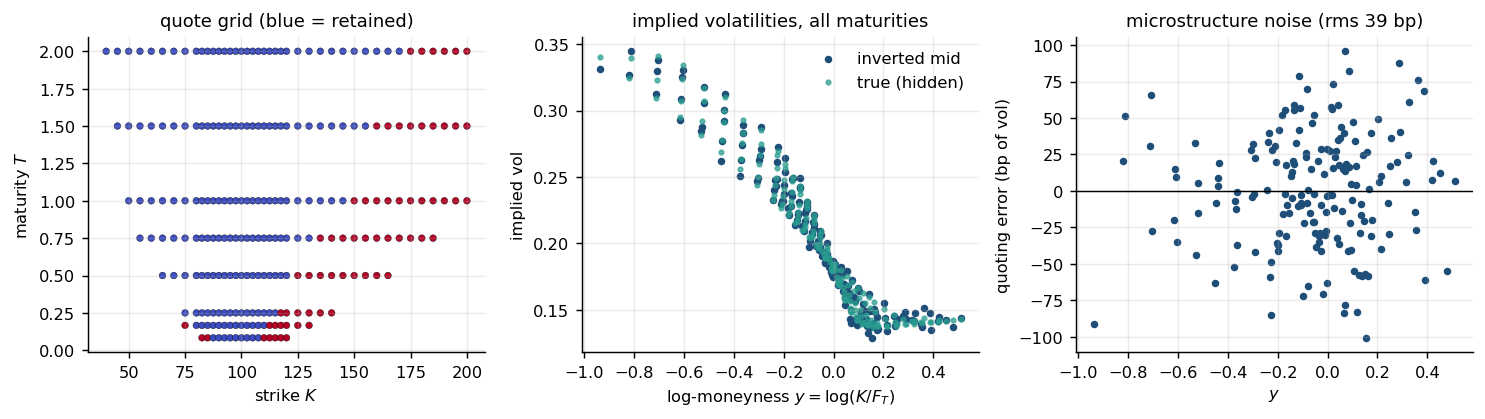

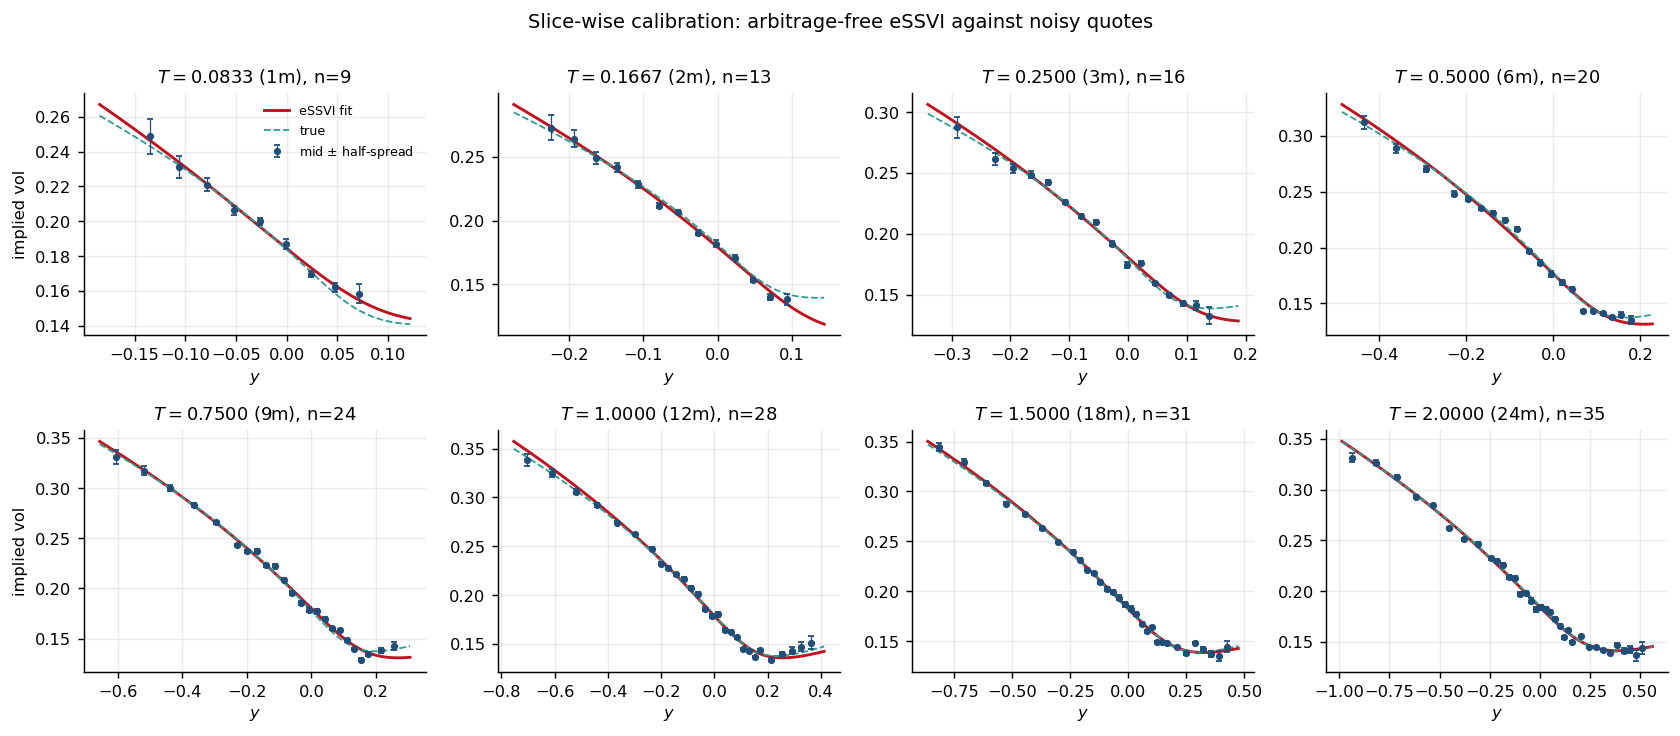

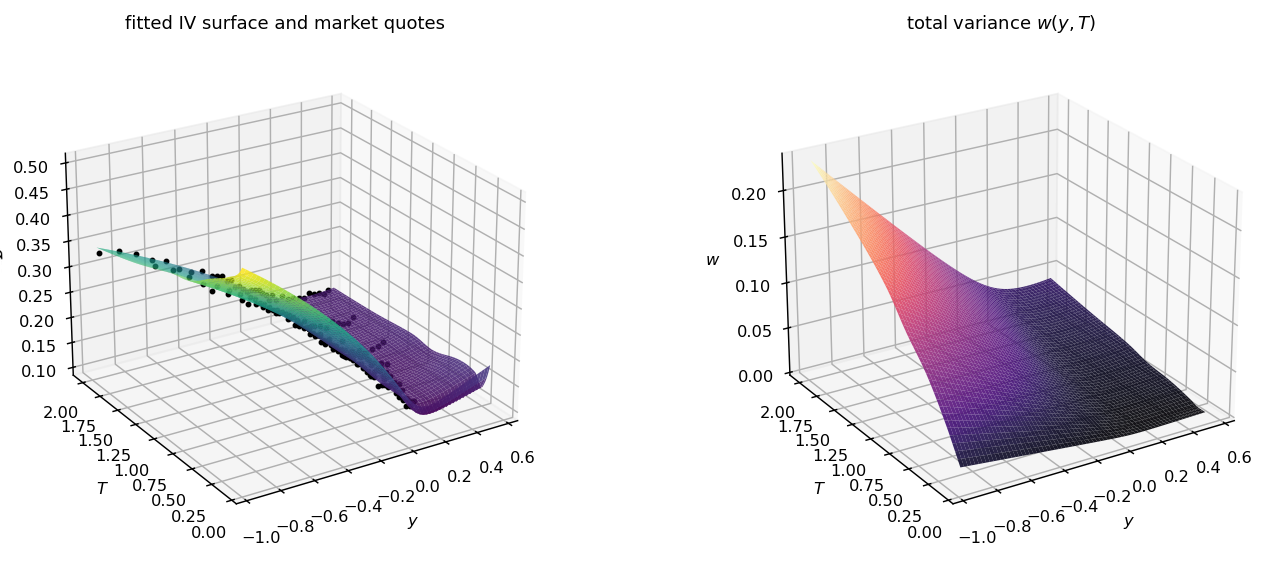

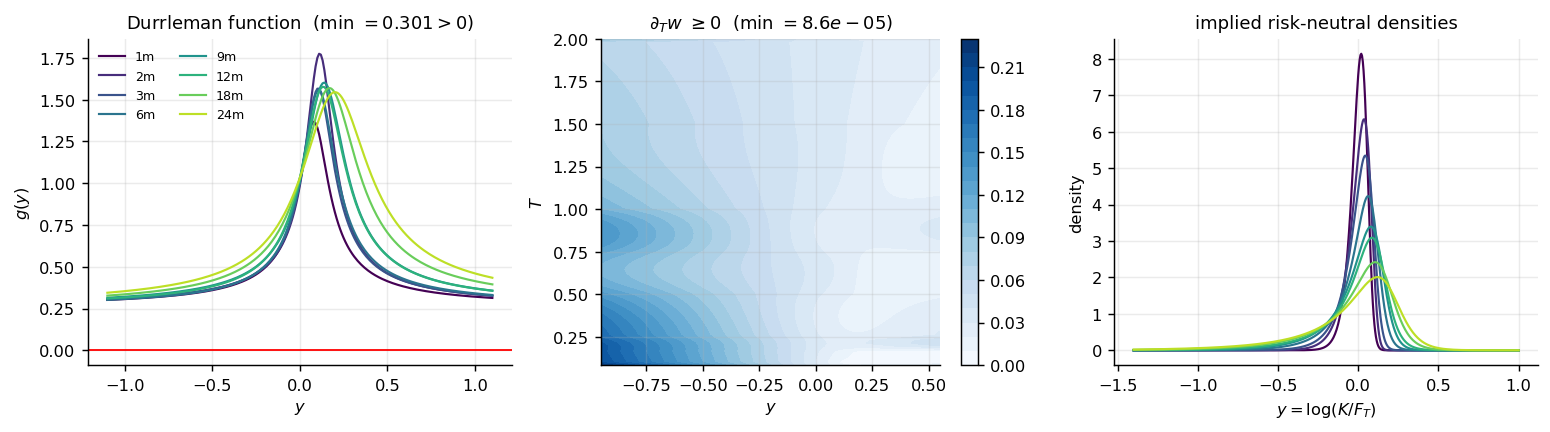

In [10]:
# ------------------------------------------------------- Fig 1: the raw market
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.3))
sc = ax[0].scatter(quotes.K, quotes["T"], c=np.where(quotes.liquid, 1, 0),
                   cmap="coolwarm_r", s=14, edgecolor="k", linewidth=.2)
ax[0].set(xlabel="strike $K$", ylabel="maturity $T$", title="quote grid (blue = retained)")
ax[1].scatter(mkt.logm, mkt.iv_mid, s=10, c=C_MKT, label="inverted mid")
ax[1].scatter(mkt.logm, mkt.iv_exact, s=6, c=C_TRUE, alpha=.7, label="true (hidden)")
ax[1].set(xlabel=r"log-moneyness $y=\log(K/F_T)$", ylabel="implied vol",
          title="implied volatilities, all maturities")
ax[1].legend()
ax[2].scatter(mkt.logm, mkt.iv_err * 1e4, s=10, c=C_MKT)
ax[2].axhline(0, color="k", lw=.8)
ax[2].set(xlabel=r"$y$", ylabel="quoting error (bp of vol)",
          title=f"microstructure noise (rms {np.sqrt((mkt.iv_err**2).mean())*1e4:.0f} bp)")
fig.tight_layout(); fig.savefig(f"{FIG}/f01_market.png"); plt.show()

# --------------------------------------------------- Fig 2: slice-by-slice fit
Ts = np.sort(mkt["T"].unique())
fig, axes = plt.subplots(2, 4, figsize=(13, 5.6), sharex=False)
for a, T in zip(axes.ravel(), Ts):
    s = mkt[mkt["T"] == T].sort_values("logm")
    yy = np.linspace(s.logm.min() - .05, s.logm.max() + .05, 300)
    a.plot(yy, SURF.iv(yy, T), color=C_FIT, lw=1.6, label="eSSVI fit")
    Kt = S0 * np.exp((r - q) * T) * np.exp(yy)
    ivt = np.array([implied_vol(float(heston_price(S0, np.array([k]), T, r, q, HP)),
                                S0, k, T, r, q, "c") for k in Kt])
    a.plot(yy, ivt, color=C_TRUE, lw=1.0, ls="--", label="true")
    a.errorbar(s.logm, s.iv_mid,
               yerr=np.abs(np.array([implied_vol(b, S0, k, T, r, q, kd)
                                     for b, k, kd in zip(s.ask, s.K, s["kind"])]) - s.iv_mid),
               fmt="o", ms=3, color=C_MKT, lw=.7, capsize=1.5, label="mid $\\pm$ half-spread")
    a.set_title(f"$T={T:.4f}$ ({T*12:.0f}m), n={len(s)}")
    a.set_xlabel("$y$")
axes[0, 0].set_ylabel("implied vol"); axes[1, 0].set_ylabel("implied vol")
axes[0, 0].legend(fontsize=7)
fig.suptitle("Slice-wise calibration: arbitrage-free eSSVI against noisy quotes", y=1.0)
fig.tight_layout(); fig.savefig(f"{FIG}/f02_smiles.png"); plt.show()

# --------------------------------------------- Fig 3: the implied-vol surface
yg = np.linspace(-0.95, 0.55, 140)
tg = np.linspace(Ts[0], Ts[-1], 120)
YG, TG = np.meshgrid(yg, tg, indexing="ij")
IVG = SURF.iv(YG, TG)
fig = plt.figure(figsize=(12, 4.4))
a1 = fig.add_subplot(1, 2, 1, projection="3d")
a1.plot_surface(YG, TG, IVG, cmap="viridis", alpha=.88, linewidth=0, antialiased=True,
                rstride=2, cstride=2)
a1.scatter(mkt.logm, mkt["T"], mkt.iv_mid, c="k", s=5, depthshade=False)
a1.set(xlabel="$y$", ylabel="$T$", zlabel=r"$\sigma_{BS}$",
       title="fitted IV surface and market quotes")
a1.view_init(24, -122)
a2 = fig.add_subplot(1, 2, 2, projection="3d")
WG = SURF.w(YG, TG)
a2.plot_surface(YG, TG, WG, cmap="magma", alpha=.9, linewidth=0, rstride=2, cstride=2)
a2.set(xlabel="$y$", ylabel="$T$", zlabel="$w$", title=r"total variance $w(y,T)$")
a2.view_init(24, -122)
fig.tight_layout(); fig.savefig(f"{FIG}/f03_iv_surface.png"); plt.show()

# ------------------------------------------------- Fig 4: arbitrage diagnostics
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
cmap = plt.cm.viridis(np.linspace(0, .9, len(Ts)))
for c, T in zip(cmap, Ts):
    ax[0].plot(Y_AUDIT, SURF.durrleman(Y_AUDIT, T), color=c, lw=1.2, label=f"{T*12:.0f}m")
ax[0].axhline(0, color="r", lw=1)
ax[0].set(xlabel="$y$", ylabel="$g(y)$",
          title=f"Durrleman function  (min $={AUDIT['min_durrleman']:.3f}>0$)")
ax[0].legend(ncol=2, fontsize=7)
dwT = SURF.dw_dT(YG, TG)
im = ax[1].contourf(YG, TG, dwT, levels=24, cmap="Blues")
plt.colorbar(im, ax=ax[1])
ax[1].set(xlabel="$y$", ylabel="$T$",
          title=r"$\partial_T w\ \geq 0$" + f"  (min $={AUDIT['min_dw_dT']:.1e}$)")
for c, T in zip(cmap, Ts):
    yy = np.linspace(-1.4, 1.0, 500)
    ax[2].plot(yy, SURF.risk_neutral_density(yy, T), color=c, lw=1.2)
ax[2].set(xlabel=r"$y=\log(K/F_T)$", ylabel="density",
          title="implied risk-neutral densities")
fig.tight_layout(); fig.savefig(f"{FIG}/f04_arbitrage.png"); plt.show()


## 9. Why naive differentiation fails

We now make the ill-posedness quantitative, then show what happens if one ignores it and
applies Dupire's formula directly to the quote ladder.

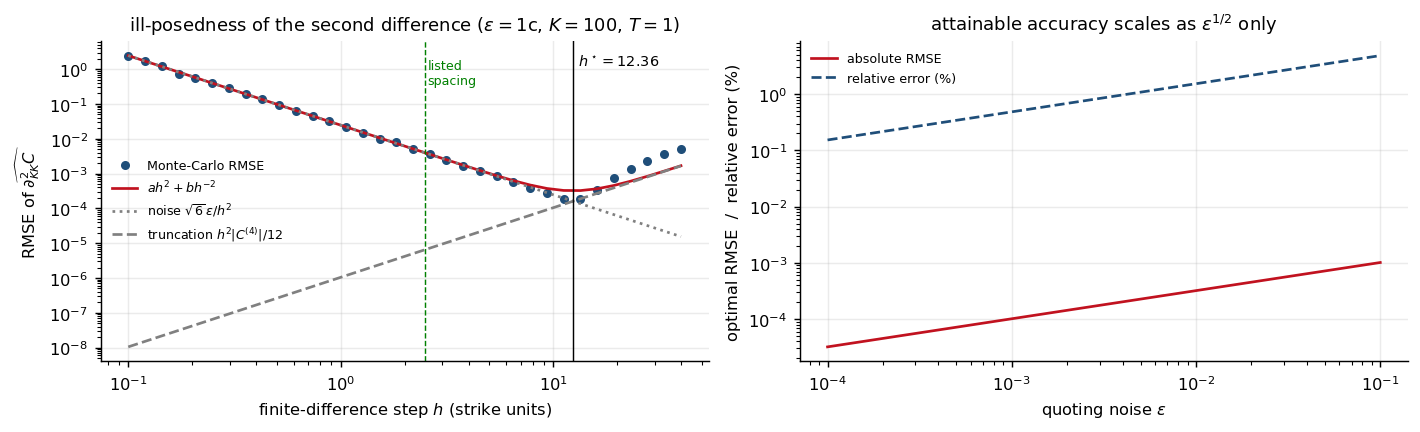

C''(K) = 0.020968,  C4 = 1.259e-05,  h* = 12.362 (listed strike spacing = 2.5)

Naive Dupire on the quote grid: 160 usable nodes, 42 (26.2%) inadmissible (negative or > 200% vol).


  on the remaining nodes: rms error vs regularised estimate = 0.181 in volatility units.


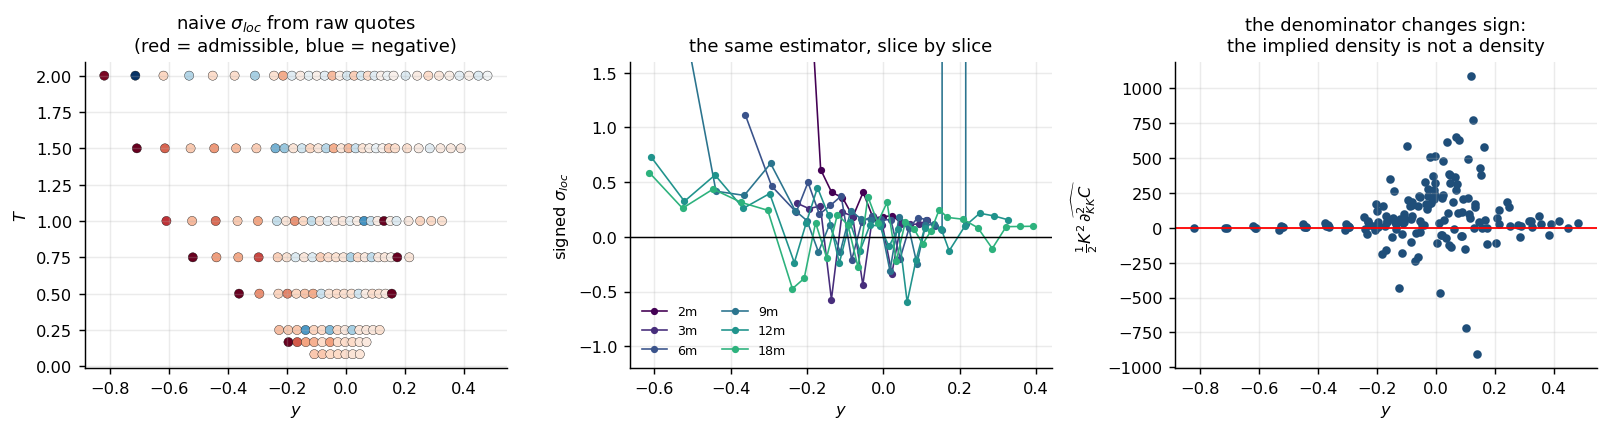

In [11]:
"""Why differentiating quotes directly cannot work.

Let :math:`\\widehat C(K)=C(K)+\\varepsilon_K` with i.i.d. noise of standard
deviation :math:`\\epsilon`.  The three-point second difference has error

.. math::
   \\mathbb{E}\\big[\\widehat D_h - C''\\big] = \\tfrac{h^2}{12}C^{(4)} + O(h^4),
   \\qquad \\operatorname{sd}\\big(\\widehat D_h\\big)=\\frac{\\sqrt6\\,\\epsilon}{h^2},

so the root-mean-square error behaves as :math:`a h^2 + b h^{-2}` with
:math:`a=|C^{(4)}|/12` and :math:`b=\\sqrt6\\,\\epsilon`.  It is minimised at

.. math:: h^\\star=\\Big(\\tfrac{b}{a}\\Big)^{1/4}
          =\\Big(\\tfrac{12\\sqrt6\\,\\epsilon}{|C^{(4)}|}\\Big)^{1/4},
   \\qquad \\mathrm{RMSE}(h^\\star)=2\\sqrt{ab}\\ \\propto\\ \\epsilon^{1/2}.

Halving the noise buys only a :math:`\\sqrt2` improvement, and the optimal step is
typically *wider than the listed strike spacing*: no choice of stencil on the
quote grid rescues the estimator.  Numerical differentiation of noisy data is a
mildly ill-posed inverse problem in the sense of Hadamard, and the cure is
regularisation -- here, projection onto an arbitrage-free parametric family.
"""
# ------------------------------------- Fig 5: bias/variance trade-off in h
T_dem, K_dem = 1.0, 100.0
C_exact_fn = heston_price_fn(S0, r, q, HP)


def C_of_K(K):
    return C_exact_fn(np.asarray(K, float), np.full(np.shape(K), T_dem))


hs = np.logspace(-1.0, 1.6, 34)
eps = 0.01          # 1 cent of quoting noise
rng_d = np.random.default_rng(1234)
n_rep = 400
C4 = ((C_of_K(K_dem + 2 * 0.5) - 4 * C_of_K(K_dem + 0.5) + 6 * C_of_K(K_dem)
       - 4 * C_of_K(K_dem - 0.5) + C_of_K(K_dem - 2 * 0.5)) / 0.5 ** 4)
true_d2 = (C_of_K(K_dem + .05) - 2 * C_of_K(K_dem) + C_of_K(K_dem - .05)) / .05 ** 2
emp = []
for h in hs:
    base = np.array([C_of_K(K_dem + h), C_of_K(K_dem), C_of_K(K_dem - h)]).ravel()
    noise = rng_d.normal(0, eps, size=(n_rep, 3))
    est = (base[0] + noise[:, 0] - 2 * (base[1] + noise[:, 1])
           + base[2] + noise[:, 2]) / h ** 2
    emp.append(np.sqrt(np.mean((est - true_d2) ** 2)))
emp = np.array(emp)
a_th, b_th = abs(float(C4)) / 12.0, np.sqrt(6.0) * eps
theo = a_th * hs ** 2 + b_th / hs ** 2
h_star = (b_th / a_th) ** 0.25

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].loglog(hs, emp, "o", ms=4, color=C_MKT, label="Monte-Carlo RMSE")
ax[0].loglog(hs, theo, "-", color=C_FIT, label=r"$a h^2 + b h^{-2}$")
ax[0].loglog(hs, b_th / hs ** 2, ":", color="gray", label=r"noise $\sqrt{6}\,\epsilon/h^2$")
ax[0].loglog(hs, a_th * hs ** 2, "--", color="gray", label=r"truncation $h^2|C^{(4)}|/12$")
ax[0].axvline(h_star, color="k", lw=.8)
ax[0].axvline(2.5, color="green", lw=.8, ls="--")
ax[0].text(h_star * 1.06, emp.max() * .5, f"$h^\\star={h_star:.2f}$", fontsize=8)
ax[0].text(2.55, emp.max() * .15, "listed\nspacing", fontsize=7, color="green")
ax[0].set(xlabel="finite-difference step $h$ (strike units)",
          ylabel=r"RMSE of $\widehat{\partial^2_{KK}C}$",
          title=f"ill-posedness of the second difference ($\\epsilon=${eps*100:.0f}c, "
                f"$K={K_dem:.0f}$, $T={T_dem:.0f}$)")
ax[0].legend(fontsize=7)

eps_grid = np.logspace(-4, -1, 16)
rm = [2 * np.sqrt(a_th * np.sqrt(6) * e) for e in eps_grid]
ax[1].loglog(eps_grid, rm, "-", color=C_FIT)
ax[1].loglog(eps_grid, np.array(rm) / abs(float(true_d2)) * 100, "--", color=C_MKT)
ax[1].set(xlabel=r"quoting noise $\epsilon$", ylabel="optimal RMSE  /  relative error (%)",
          title=r"attainable accuracy scales as $\epsilon^{1/2}$ only")
ax[1].legend(["absolute RMSE", "relative error (%)"], fontsize=7)
fig.tight_layout(); fig.savefig(f"{FIG}/f05_illposed.png"); plt.show()
print(f"C''(K) = {float(true_d2):.6f},  C4 = {float(C4):.3e},  h* = {h_star:.3f} "
      f"(listed strike spacing = 2.5)")

# ------------------------- Fig 6: Dupire applied directly to the quote ladder
naive = naive_local_var_from_quotes(mkt, S0, r, q, price_col="mid")
naive = naive.dropna(subset=["locvar"])
bad = (naive.locvar <= 0) | (naive.locvar > 4.0)
print(f"\nNaive Dupire on the quote grid: {len(naive)} usable nodes, "
      f"{int(bad.sum())} ({100*bad.mean():.1f}%) inadmissible "
      f"(negative or > 200% vol).")
naive_ok = naive[~bad]
ref = np.array([float(local_var_from_surface(SURF, row.logm, row["T"]))
                for _, row in naive_ok.iterrows()])
print(f"  on the remaining nodes: rms error vs regularised estimate = "
      f"{np.sqrt(np.nanmean((np.sqrt(naive_ok.locvar)-np.sqrt(np.clip(ref,1e-8,None)))**2)):.3f} "
      f"in volatility units.")

fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.4))
sgn = np.sign(naive.locvar)
ax[0].scatter(naive.logm, naive["T"], c=np.clip(np.sqrt(np.abs(naive.locvar)) * sgn, -1, 1),
              cmap="RdBu_r", s=26, vmin=-1, vmax=1, edgecolor="k", linewidth=.2)
ax[0].set(xlabel="$y$", ylabel="$T$",
          title="naive $\\sigma_{loc}$ from raw quotes\n(red = admissible, blue = negative)")
for c, T in zip(cmap, Ts[1:-1]):
    s = naive[naive["T"] == T].sort_values("logm")
    ax[1].plot(s.logm, np.sign(s.locvar) * np.sqrt(np.abs(s.locvar)), "o-", ms=3,
               color=c, lw=.9, label=f"{T*12:.0f}m")
ax[1].axhline(0, color="k", lw=.8)
ax[1].set(ylim=(-1.2, 1.6), xlabel="$y$", ylabel=r"signed $\sigma_{loc}$",
          title="the same estimator, slice by slice")
ax[1].legend(fontsize=7, ncol=2)
ax[2].scatter(naive.logm, naive.den, s=14, c=C_MKT)
ax[2].axhline(0, color="r", lw=1)
ax[2].set(xlabel="$y$", ylabel=r"$\frac{1}{2}K^2\,\widehat{\partial^2_{KK}C}$",
          title="the denominator changes sign:\nthe implied density is not a density")
fig.tight_layout(); fig.savefig(f"{FIG}/f06_naive_dupire.png"); plt.show()


## 10. The local-volatility surface

Two independent checks. First, an *internal* one: Dupire's price form and Gatheral's
implied-variance form are applied to the same calibrated surface and must agree — they are the
same theorem in different coordinates, so any discrepancy is an implementation bug. Second, an
*external* one: because we know the data-generating process, the exact local-volatility
surface can be computed from machine-accuracy Heston prices and used as ground truth.

Cross-validation: Gatheral implied-variance form vs Dupire price form, on the same surface
        T  max_abs_diff       rel
3.000e-01     4.843e-05 3.439e-04
6.200e-01     9.513e-06 7.933e-05
8.800e-01     3.036e-05 1.226e-04
1.250e+00     4.443e-06 2.369e-05
1.750e+00     2.099e-06 1.552e-05



Local volatility vs ground truth
  inside the quoted region : rmse =  1.38 vol pts, max = 10.77
  outside (extrapolated)   : rmse =  5.90 vol pts, max = 37.45
  core region |y|<0.7*band : rmse =  0.98 vol pts, max =  6.87


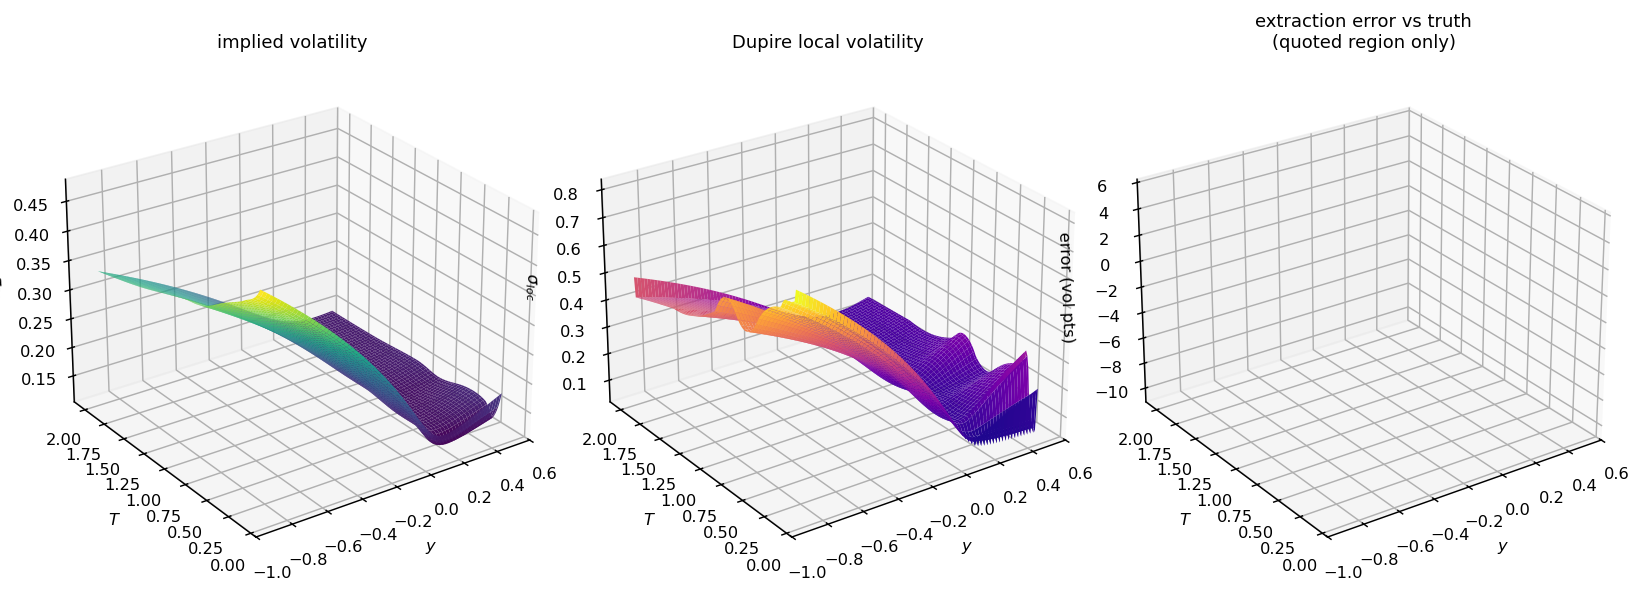

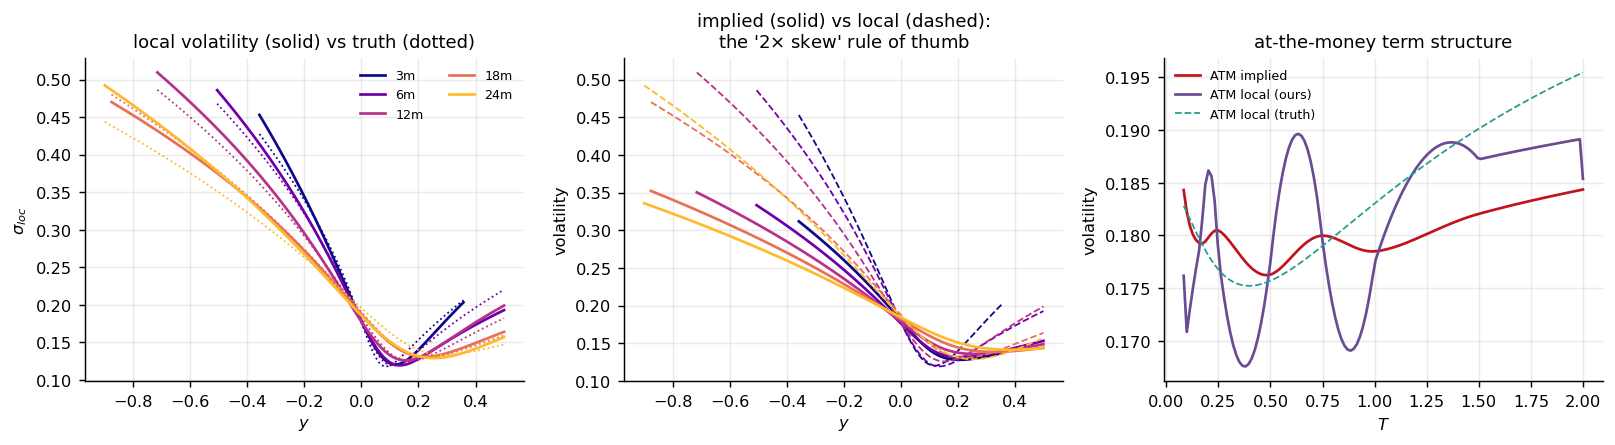

In [12]:
# ------------------------------------------------ the regularised extraction
Y_LV = np.linspace(-0.90, 0.50, 150)
T_LV = np.linspace(Ts[0], Ts[-1], 130)
YL, TL = np.meshgrid(Y_LV, T_LV, indexing="ij")
LV = local_vol_from_surface(SURF, YL, TL)
KL = S0 * np.exp((r - q) * TL) * np.exp(YL)

# ------------------------------------- cross-validation of the two Dupire forms
pf_surf = surface_to_call_price(SURF, S0, r, q)
Kx = np.array([70.0, 85.0, 95.0, 100.0, 110.0, 125.0])
rows = []
for T in [0.30, 0.62, 0.88, 1.25, 1.75]:
    y = np.log(Kx / (S0 * np.exp((r - q) * T)))
    g_form = np.sqrt(np.maximum(local_var_from_surface(SURF, y, T), 0))
    p_form, _, _ = local_var_from_prices(pf_surf, Kx, np.full_like(Kx, T), r, q)
    rows.append(dict(T=T, max_abs_diff=float(np.nanmax(np.abs(g_form - np.sqrt(np.maximum(p_form, 0))))),
                     rel=float(np.nanmax(np.abs(g_form / np.sqrt(np.maximum(p_form, 1e-12)) - 1)))))
xval = pd.DataFrame(rows)
print("Cross-validation: Gatheral implied-variance form vs Dupire price form, "
      "on the same surface")
print(xval.to_string(index=False, float_format=lambda v: f"{v:.3e}"))

# ------------------------------------------------------ ground truth (hidden)
pf_true = heston_price_fn(S0, r, q, HP)


def true_local_vol(y, T):
    K = S0 * np.exp((r - q) * T) * np.exp(y)
    v, num, den = local_var_from_prices(pf_true, K, np.full_like(K, T, dtype=float), r, q)
    v = np.where(den > 1e-10, v, np.nan)
    return np.sqrt(np.clip(v, 1e-8, 9.0))


mask_in = np.array([[abs(Y_LV[i]) <= BAND(T_LV[j]) for j in range(len(T_LV))]
                    for i in range(len(Y_LV))])
# the ground truth needs machine-accurate Fourier prices, so it is evaluated on a
# deliberately coarser grid: it is a benchmark, not the deliverable.
SUB_Y, SUB_T = slice(None, None, 3), slice(None, None, 4)
LV_TRUE = np.full_like(LV, np.nan)
for j in range(0, len(T_LV), 4):
    LV_TRUE[::3, j] = true_local_vol(Y_LV[::3], T_LV[j])
ERR = LV - LV_TRUE
err_in = ERR[mask_in & np.isfinite(ERR)]
err_out = ERR[(~mask_in) & np.isfinite(ERR)]
print(f"\nLocal volatility vs ground truth")
print(f"  inside the quoted region : rmse = {np.sqrt(np.mean(err_in**2))*100:5.2f} vol pts, "
      f"max = {np.max(np.abs(err_in))*100:5.2f}")
print(f"  outside (extrapolated)   : rmse = {np.sqrt(np.mean(err_out**2))*100:5.2f} vol pts, "
      f"max = {np.max(np.abs(err_out))*100:5.2f}")
mask_core = np.array([[abs(Y_LV[i]) <= 0.7 * BAND(T_LV[j]) for j in range(len(T_LV))]
                      for i in range(len(Y_LV))])
err_core = ERR[mask_core & np.isfinite(ERR)]
print(f"  core region |y|<0.7*band : rmse = {np.sqrt(np.mean(err_core**2))*100:5.2f} vol pts, "
      f"max = {np.max(np.abs(err_core))*100:5.2f}")

# ------------------------------------------------- Fig 7: local-vol surface 3D
fig = plt.figure(figsize=(12.5, 4.6))
a1 = fig.add_subplot(1, 3, 1, projection="3d")
a1.plot_surface(YL, TL, SURF.iv(YL, TL), cmap="viridis", linewidth=0, rstride=2, cstride=2)
a1.set(xlabel="$y$", ylabel="$T$", zlabel=r"$\sigma_{BS}$", title="implied volatility")
a1.view_init(26, -125)
a2 = fig.add_subplot(1, 3, 2, projection="3d")
a2.plot_surface(YL, TL, LV, cmap="plasma", linewidth=0, rstride=2, cstride=2)
a2.set(xlabel="$y$", ylabel="$T$", zlabel=r"$\sigma_{loc}$",
       title="Dupire local volatility")
a2.view_init(26, -125)
a3 = fig.add_subplot(1, 3, 3, projection="3d")
a3.plot_surface(YL, TL, np.where(mask_in, ERR, np.nan) * 100, cmap="coolwarm",
                linewidth=0, rstride=2, cstride=2,
                vmin=-np.nanpercentile(np.abs(err_in) * 100, 99),
                vmax=np.nanpercentile(np.abs(err_in) * 100, 99))
a3.set(xlabel="$y$", ylabel="$T$", zlabel="error (vol pts)",
       title="extraction error vs truth\n(quoted region only)")
a3.view_init(26, -125)
fig.tight_layout(); fig.savefig(f"{FIG}/f07_locvol_3d.png"); plt.show()

# ---------------------------------------- Fig 8: slices, and the skew rule of thumb
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.5))
for c, T in zip(plt.cm.plasma(np.linspace(0, .85, 5)), [0.25, 0.5, 1.0, 1.5, 2.0]):
    yy = np.linspace(-min(0.9, BAND(T)), min(0.5, BAND(T)), 200)
    ax[0].plot(yy, local_vol_from_surface(SURF, yy, T), color=c, lw=1.5, label=f"{T*12:.0f}m")
    ax[0].plot(yy, true_local_vol(yy, T), color=c, lw=1.0, ls=":")
    ax[1].plot(yy, SURF.iv(yy, T), color=c, lw=1.5)
    ax[1].plot(yy, local_vol_from_surface(SURF, yy, T), color=c, lw=1.0, ls="--")
ax[0].set(xlabel="$y$", ylabel=r"$\sigma_{loc}$",
          title="local volatility (solid) vs truth (dotted)")
ax[0].legend(fontsize=7, ncol=2)
ax[1].set(xlabel="$y$", ylabel="volatility",
          title=r"implied (solid) vs local (dashed):"
                "\nthe '2$\\times$ skew' rule of thumb")
atm_i = np.array([float(SURF.iv(0.0, t)) for t in T_LV])
atm_l = np.array([float(local_vol_from_surface(SURF, 0.0, t)) for t in T_LV])
atm_t = np.array([float(true_local_vol(np.array([0.0]), t)[0]) for t in T_LV])
ax[2].plot(T_LV, atm_i, color=C_FIT, lw=1.5, label="ATM implied")
ax[2].plot(T_LV, atm_l, color=C_LV, lw=1.5, label="ATM local (ours)")
ax[2].plot(T_LV, atm_t, color=C_TRUE, lw=1.0, ls="--", label="ATM local (truth)")
ax[2].set(xlabel="$T$", ylabel="volatility", title="at-the-money term structure")
ax[2].legend(fontsize=7)
fig.tight_layout(); fig.savefig(f"{FIG}/f08_locvol_slices.png"); plt.show()


## 11. Dupire consistency and Monte-Carlo convergence

The decisive test of the whole construction: simulate the local-volatility SDE and reprice the
very European options we started from. Dupire's theorem says the implied volatilities must come
back. Any residual is discretisation bias, interpolation error, or a mistake.

Local-vol table: (121, 221), sigma in [0.024, 0.845]



Dupire consistency test -- Monte Carlo under sigma_loc vs the calibrated surface
        T         K     iv_mc   iv_surf   iv_true      d_bp     se_bp
   0.2500   80.0000    0.2658    0.2693    0.2664  -34.7139    7.3089
   0.2500   90.0000    0.2229    0.2258    0.2264  -28.9275    4.5708
   0.2500  100.0000    0.1791    0.1816    0.1806  -24.3619    3.0747
   0.2500  110.0000    0.1417    0.1434    0.1424  -17.7197    2.8190
   0.5000   70.0000    0.2936    0.2956    0.2927  -20.4925    8.2613
   0.5000   80.0000    0.2545    0.2564    0.2569  -19.7983    5.7889
   0.5000   90.0000    0.2162    0.2172    0.2193  -10.2283    4.1587
   0.5000  100.0000    0.1777    0.1782    0.1791   -4.6082    3.1070
   0.5000  110.0000    0.1453    0.1456    0.1452   -2.7086    2.7834
   0.5000  120.0000    0.1317    0.1321    0.1374   -3.8074    4.1248
   1.0000   70.0000    0.2767    0.2773    0.2752   -6.4173    6.1143
   1.0000   80.0000    0.2440    0.2444    0.2437   -4.0467    4.8347
   1.000

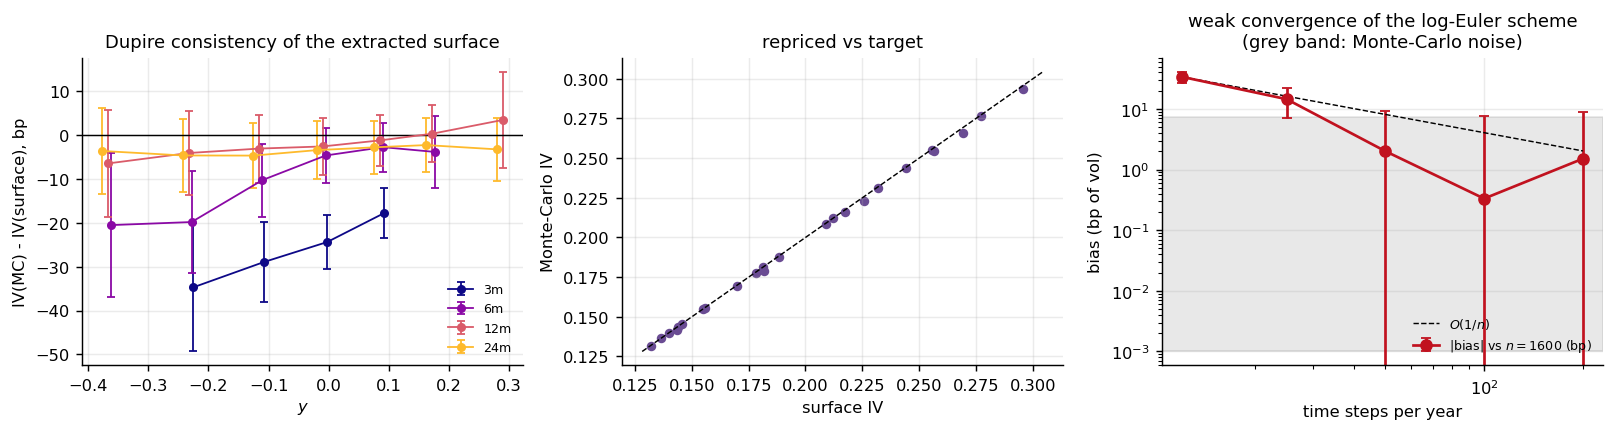


Weak convergence, ATM T=1 (bp of implied vol, reference n=1600):
  n=12: 33.9+-7.3, n=25: 14.5+-7.3, n=50: 2.0+-7.3, n=100: 0.3+-7.3, n=200: 1.5+-7.3

Brownian-bridge barrier correction vs the exact Black--Scholes formula


        B        mc        se     exact         z
110.00000   0.11807   0.00137   0.11761   0.33552
120.00000   1.10839   0.00566   1.11302  -0.81760
130.00000   3.00761   0.01077   3.01929  -1.08481
150.00000   6.42501   0.01858   6.44906  -1.29488


In [13]:
# ------------------------------------------------------- the local-vol engine
LVG = LocalVolGrid(SURF, S0, r, q, y_band=0.95, T_min=float(Ts[0]), T_max=float(Ts[-1]),
                   n_y=221, n_t=121)
print(f"Local-vol table: {LVG.table.shape}, sigma in "
      f"[{LVG.table.min():.3f}, {LVG.table.max():.3f}]")

N_PATHS, STEPS_PER_YEAR = 200_000, 250

# --------------------------------- Fig 9: Dupire consistency (European reprice)
val_rows = []
for T in [0.25, 0.5, 1.0, 2.0]:
    res = simulate_lv(LVG, S0, r, q, T, max(int(STEPS_PER_YEAR * T), 60), N_PATHS, seed=101)
    F = S0 * np.exp((r - q) * T)
    for K in [70, 80, 90, 100, 110, 120, 135]:
        if abs(np.log(K / F)) > 0.85 * BAND(T):
            continue   # keep only strikes the simulation can resolve
        # skip contracts too cheap for a Monte Carlo of this size to resolve: below a
        # couple of cents the implied vol of the estimate is sampling error, not surface
        if float(bs_price(S0, float(K), T, r, q,
                          float(SURF.iv(np.log(K / F), T)), "c")) < 0.02:
            continue
        m, se = price_european(res, float(K), r, T, "c", control_F=F)
        if m <= 1e-6 or m < 20.0 * se:   # payoff too rare to resolve at this budget
            continue
        iv_mc = implied_vol(m, S0, float(K), T, r, q, "c")
        iv_su = float(SURF.iv(np.log(K / F), T))
        iv_tr = implied_vol(float(heston_price(S0, np.array([float(K)]), T, r, q, HP)),
                            S0, float(K), T, r, q, "c")
        vega = float(bs_vega(S0, float(K), T, r, q, iv_su))
        val_rows.append(dict(T=T, K=float(K), y=float(np.log(K / F)), price=m, se=se,
                             iv_mc=iv_mc, iv_surf=iv_su, iv_true=iv_tr,
                             d_bp=1e4 * (iv_mc - iv_su), se_bp=1e4 * se / max(vega, 1e-8)))
VAL = pd.DataFrame(val_rows)
print("\nDupire consistency test -- Monte Carlo under sigma_loc vs the calibrated surface")
print(VAL[["T", "K", "iv_mc", "iv_surf", "iv_true", "d_bp", "se_bp"]]
      .to_string(index=False, float_format=lambda v: f"{v:9.4f}"))
print(f"\n  rms |IV(MC) - IV(surface)| = {np.sqrt((VAL.d_bp**2).mean()):.1f} bp "
      f"(mean Monte-Carlo standard error {VAL.se_bp.mean():.1f} bp)")

fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.4))
for c, T in zip(plt.cm.plasma(np.linspace(0, .85, 4)), [0.25, 0.5, 1.0, 2.0]):
    s = VAL[VAL["T"] == T]
    ax[0].errorbar(s.y, s.d_bp, yerr=2 * s.se_bp, fmt="o-", ms=4, lw=1, color=c,
                   capsize=2, label=f"{T*12:.0f}m")
ax[0].axhline(0, color="k", lw=.8)
ax[0].set(xlabel="$y$", ylabel="IV(MC) - IV(surface), bp",
          title="Dupire consistency of the extracted surface")
ax[0].legend(fontsize=7)
ax[1].scatter(VAL.iv_surf, VAL.iv_mc, s=18, c=C_LV)
lim = [VAL.iv_surf.min() * .97, VAL.iv_surf.max() * 1.03]
ax[1].plot(lim, lim, "k--", lw=.8)
ax[1].set(xlabel="surface IV", ylabel="Monte-Carlo IV", title="repriced vs target")

# ------------------------------------------- convergence: bias and variance
# Weak convergence must be measured against a *fine-grid* run of the same scheme,
# not against the surface: the surface target also carries the interpolation error of
# the local-vol table, which does not vanish as the time step shrinks.
K_ATM = S0 * np.exp((r - q) * 1.0)
steps_list = [12, 25, 50, 100, 200]
N_CONV = 300_000
ref = simulate_lv(LVG, S0, r, q, 1.0, 1600, N_CONV, seed=77)
ref_px, ref_se = price_european(ref, K_ATM, r, 1.0, "c", control_F=K_ATM)
ref_iv = implied_vol(ref_px, S0, K_ATM, 1.0, r, q, "c")
bias, bse = [], []
for ns in steps_list:
    res = simulate_lv(LVG, S0, r, q, 1.0, ns, N_CONV, seed=77)
    m, se = price_european(res, K_ATM, r, 1.0, "c", control_F=K_ATM)
    iv = implied_vol(m, S0, K_ATM, 1.0, r, q, "c")
    vg = float(bs_vega(S0, K_ATM, 1.0, r, q, iv))
    bias.append(abs(iv - ref_iv) * 1e4)
    bse.append(1e4 * np.hypot(se, ref_se) / vg)
ax[2].errorbar(steps_list, bias, yerr=2 * np.array(bse), fmt="o-", color=C_FIT, capsize=3,
               label="|bias| vs $n=1600$ (bp)")
ax[2].loglog(steps_list, bias[0] * (np.array(steps_list) / steps_list[0]) ** -1.0,
             "k--", lw=.8, label=r"$O(1/n)$")
ax[2].axhspan(1e-3, 2 * np.mean(bse), color="grey", alpha=.18)
ax[2].set(xscale="log", yscale="log", xlabel="time steps per year",
          ylabel="bias (bp of vol)",
          title="weak convergence of the log-Euler scheme\n(grey band: Monte-Carlo noise)")
ax[2].legend(fontsize=7)
fig.tight_layout(); fig.savefig(f"{FIG}/f09_mc_validation.png"); plt.show()
print("\nWeak convergence, ATM T=1 (bp of implied vol, reference n=1600):")
print("  " + ", ".join(f"n={n}: {b:.1f}+-{2*e:.1f}" for n, b, e in zip(steps_list, bias, bse)))


# ------------------------- independent check of the barrier machinery
print("\nBrownian-bridge barrier correction vs the exact Black--Scholes formula")
from scipy.integrate import quad as _quad
_sg, _T = 0.20, 1.0
def _uo_exact(K, B):
    nu = r - q - 0.5 * _sg ** 2
    b, sd = np.log(B / S0), _sg * np.sqrt(_T)
    f = lambda x: (S0 * np.exp(x) - K) * (norm.pdf((x - nu * _T) / sd)
        - np.exp(2 * nu * b / _sg ** 2) * norm.pdf((x - 2 * b - nu * _T) / sd)) / sd
    return np.exp(-r * _T) * _quad(f, np.log(K / S0), b, limit=400)[0]
chk = []
for B in [110.0, 120.0, 130.0, 150.0]:
    rr = simulate_bs(S0, r, q, _sg, _T, 400, 300_000, seed=9, barrier=(B, "up"))
    m_, se_ = price_barrier(rr, 100.0, r, _T)
    ex_ = _uo_exact(100.0, B)
    chk.append(dict(B=B, mc=m_, se=se_, exact=ex_, z=(m_ - ex_) / max(se_, 1e-12)))
BARCHK = pd.DataFrame(chk)
print(BARCHK.to_string(index=False, float_format=lambda v: f"{v:9.5f}"))


## 12. Exotics and model risk

Local volatility is the unique *diffusion* consistent with all vanillas, but not the unique
*model*. Here we price six payoffs under three engines that agree on every European option:
the calibrated local-volatility model, the true Heston dynamics, and flat Black--Scholes at the
one-year ATM volatility. The spread between local volatility and Heston is the honest measure
of what the vanilla market leaves undetermined.

Flat Black--Scholes benchmark volatility (1y ATM implied) = 0.1785


Barrier engine validation (flat Black--Scholes, B=130): MC 3.4739 +- 0.0139 vs closed form 3.4771   (z = -0.23)



Exotic prices, T = 1y, 200,000 paths, 250 steps
                               Local vol  Heston (truth)  Black--Scholes (flat)  LV vs Heston (%)  BS vs Heston (%)
European call K=100               7.6074          7.6348                 7.5241           -0.3580           -1.4494
Up-and-out call B=130             5.9301          6.2530                 3.4827           -5.1637          -44.3026
Asian call K=100 (12 fix.)        4.5873          4.6302                 4.5890           -0.9266           -0.8902
Digital call K=110                0.3367          0.3373                 0.2801           -0.1744          -16.9389
Lookback (floating strike)       15.3181         15.1403                13.2315            1.1743          -12.6076
Cliquet 12m, cap 8% floor -8%     0.0722          0.0697                 0.0641            3.6829           -8.0178

Monte-Carlo standard errors
                               Local vol  Heston (truth)  Black--Scholes (flat)
European call K=100           

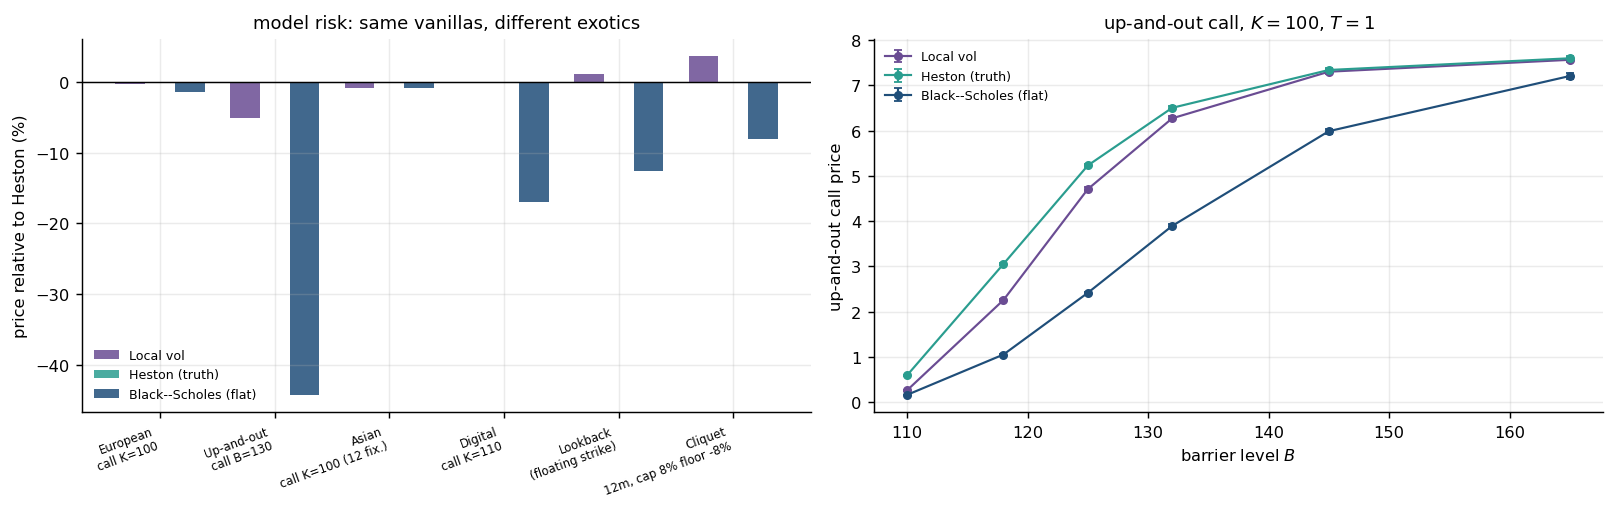


Up-and-out call as a function of the barrier
       Local vol  Heston (truth)  Black--Scholes (flat)  LV vs Heston (%)
110.0     0.2622          0.5935                 0.1609          -55.8262
118.0     2.2579          3.0546                 1.0525          -26.0803
125.0     4.7089          5.2321                 2.4166          -10.0003
132.0     6.2741          6.5061                 3.8956           -3.5656
145.0     7.3051          7.3427                 5.9897           -0.5111
165.0     7.5677          7.6017                 7.2095           -0.4471


In [14]:
"""Model risk on exotics.

All three engines reprice the same European options.  Local volatility is the
*unique* one-factor diffusion consistent with the whole surface (Dupire 1994);
Heston is the true data generating process; flat Black--Scholes is calibrated to
the single at-the-money one-year volatility.  Whatever separates their exotic
prices is not calibration error -- it is the part of the risk-neutral dynamics
that European options do not observe: the forward smile and the spot/vol
covariance.
"""
T_EX = 1.0
n_steps = 250
n_paths = 200_000
fix = list(np.arange(1, 13) / 12.0)
sigma_flat = float(SURF.iv(0.0, T_EX))
print(f"Flat Black--Scholes benchmark volatility (1y ATM implied) = {sigma_flat:.4f}")

engines = {}
engines["Local vol"] = dict(
    sim=lambda npth=n_paths, nst=n_steps, **kw:
        simulate_lv(LVG, S0, r, q, T_EX, nst, npth, seed=202, **kw), color=C_LV)
engines["Heston (truth)"] = dict(
    sim=lambda npth=n_paths, nst=n_steps, **kw:
        simulate_heston_qe(S0, r, q, HP, T_EX, nst, npth, seed=303, **kw), color=C_TRUE)
engines["Black--Scholes (flat)"] = dict(
    sim=lambda npth=n_paths, nst=n_steps, **kw:
        simulate_bs(S0, r, q, sigma_flat, T_EX, nst, npth, seed=404, **kw), color=C_MKT)

B_UP, K_EX, K_DIG = 130.0, 100.0, 110.0


def uo_call_bs(S, K, B, T, r, q, s):
    """Reiner--Rubinstein closed form for an up-and-out call (K < B). Used only to
    validate the Brownian-bridge barrier machinery against a known answer."""
    v = s * np.sqrt(T)
    lam = 1.0 + (r - q - 0.5 * s * s) / (s * s)
    x1 = np.log(S / B) / v + lam * v
    y1 = np.log(B / S) / v + lam * v
    x = np.log(S / K) / v + lam * v
    y = np.log(B * B / (S * K)) / v + lam * v
    P = lambda z: S * np.exp(-q * T) * norm.cdf(z) - K * np.exp(-r * T) * norm.cdf(z - v)
    Q = lambda z: (S * np.exp(-q * T) * (B / S) ** (2 * lam) * norm.cdf(z)
                   - K * np.exp(-r * T) * (B / S) ** (2 * lam - 2) * norm.cdf(z - v))
    return P(x) - P(x1) - Q(y) + Q(y1)


_chk = simulate_bs(S0, r, q, sigma_flat, T_EX, n_steps, n_paths, seed=909,
                   barrier=(B_UP, "up"))
_m, _se = price_barrier(_chk, K_EX, r, T_EX)
_an = uo_call_bs(S0, K_EX, B_UP, T_EX, r, q, sigma_flat)
print(f"Barrier engine validation (flat Black--Scholes, B={B_UP:g}): MC {_m:.4f} "
      f"+- {_se:.4f} vs closed form {_an:.4f}   (z = {(_m - _an) / _se:+.2f})")
results = {}
for name, cfg in engines.items():
    r_path = cfg["sim"](fixings=fix, barrier=(B_UP, "up"), need_extrema=True)
    r_plain = cfg["sim"](fixings=fix, need_extrema=True)
    F = S0 * np.exp((r - q) * T_EX)
    results[name] = {
        "European call K=100": price_european(r_plain, K_EX, r, T_EX, "c", control_F=F),
        "Up-and-out call B=130": price_barrier(r_path, K_EX, r, T_EX),
        "Asian call K=100 (12 fix.)": price_asian(r_plain, K_EX, r, T_EX),
        "Digital call K=110": price_digital(r_plain, K_DIG, r, T_EX),
        "Lookback (floating strike)": price_lookback(r_plain, r, T_EX),
        "Cliquet 12m, cap 8% floor -8%": price_cliquet(r_plain, S0, r, T_EX),
    }

EX = pd.DataFrame({k: {p: v[0] for p, v in d.items()} for k, d in results.items()})
SE = pd.DataFrame({k: {p: v[1] for p, v in d.items()} for k, d in results.items()})
EX["LV vs Heston (%)"] = 100 * (EX["Local vol"] / EX["Heston (truth)"] - 1)
EX["BS vs Heston (%)"] = 100 * (EX["Black--Scholes (flat)"] / EX["Heston (truth)"] - 1)
print(f"\nExotic prices, T = {T_EX:g}y, {n_paths:,} paths, {n_steps} steps")
print(EX.to_string(float_format=lambda v: f"{v:10.4f}"))
print("\nMonte-Carlo standard errors")
print(SE.to_string(float_format=lambda v: f"{v:10.5f}"))

# The digital is a pure test of the SLOPE of the surface: a cash-or-nothing call is the
# negative strike-derivative of the vanilla, so by the chain rule
#     Digital = e^{-rT} N(d_-) - Vega * dsigma/dK,
# the second term being the skew correction that flat Black--Scholes omits entirely.
F1 = S0 * np.exp((r - q) * T_EX)
y_dig = np.log(K_DIG / F1)
w_dig = float(SURF.w(y_dig, T_EX))
sig_dig = np.sqrt(w_dig / T_EX)
d2 = (np.log(F1 / K_DIG) - 0.5 * w_dig) / np.sqrt(w_dig)
dig_smile = float(np.exp(-r * T_EX) * norm.cdf(d2))
dsig_dK = (float(SURF.iv(np.log((K_DIG + .01) / F1), T_EX))
           - float(SURF.iv(np.log((K_DIG - .01) / F1), T_EX))) / 0.02
dig_skew = dig_smile - float(bs_vega(S0, K_DIG, T_EX, r, q, sig_dig)) * dsig_dK
dig_fd = -(float(pf_surf(np.array([K_DIG + .05]), np.array([T_EX]))[0])
           - float(pf_surf(np.array([K_DIG - .05]), np.array([T_EX]))[0])) / 0.10
print(f"\nDigital call K={K_DIG:g} -- decomposition of the skew effect")
print(f"  Black--Scholes at the smile vol, no skew term : {dig_smile:.4f}")
print(f"  plus the skew correction  -Vega*dsigma/dK     : {dig_skew:.4f}")
print(f"  finite difference  -dC/dK  on the surface     : {dig_fd:.4f}")
print(f"  local-volatility Monte Carlo                  : "
      f"{results['Local vol']['Digital call K=110'][0]:.4f} "
      f"(+-{results['Local vol']['Digital call K=110'][1]:.4f})")
print(f"  flat Black--Scholes                           : "
      f"{results['Black--Scholes (flat)']['Digital call K=110'][0]:.4f}")

# --------------------------------------------- Fig 10: exotic price comparison
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.0))
labels = list(EX.index)
xpos = np.arange(len(labels))
wdt = 0.26
for i, (name, cfg) in enumerate(engines.items()):
    rel = 100 * (EX[name] / EX["Heston (truth)"] - 1)
    ax[0].bar(xpos + (i - 1) * wdt, rel, wdt, label=name, color=cfg["color"], alpha=.85)
ax[0].axhline(0, color="k", lw=.8)
ax[0].set_xticks(xpos)
ax[0].set_xticklabels([l.replace(" ", "\n", 1) for l in labels], fontsize=6.5, rotation=20,
                      ha="right")
ax[0].set(ylabel="price relative to Heston (%)",
          title="model risk: same vanillas, different exotics")
ax[0].legend(fontsize=7)

# ---------------------------------------- Fig 10b: the barrier price profile
barriers = np.array([110., 118., 125., 132., 145., 165.])
prof = {}
for name, cfg in engines.items():
    vals, ses = [], []
    for B in barriers:
        rr = cfg["sim"](npth=120_000, nst=200, barrier=(float(B), "up"))
        m, s = price_barrier(rr, K_EX, r, T_EX)
        vals.append(m); ses.append(s)
    prof[name] = (np.array(vals), np.array(ses))
    ax[1].errorbar(barriers, vals, yerr=2 * np.array(ses), fmt="o-", ms=4, lw=1.2,
                   color=cfg["color"], capsize=2, label=name)
ax[1].set(xlabel="barrier level $B$", ylabel="up-and-out call price",
          title="up-and-out call, $K=100$, $T=1$")
ax[1].legend(fontsize=7)
fig.tight_layout(); fig.savefig(f"{FIG}/f10_exotics.png"); plt.show()

PROF = pd.DataFrame({k: v[0] for k, v in prof.items()}, index=barriers)
PROF["LV vs Heston (%)"] = 100 * (PROF["Local vol"] / PROF["Heston (truth)"] - 1)
print("\nUp-and-out call as a function of the barrier")
print(PROF.to_string(float_format=lambda v: f"{v:9.4f}"))


## 13. How much of the surface is real?

Finally, the error bar. We resample the microstructure noise, re-run the entire pipeline, and
measure the induced dispersion of $\sigma_{\mathrm{loc}}$. The ratio
$\mathrm{sd}(\sigma_{\mathrm{loc}})/\mathrm{sd}(\sigma_{\mathrm{BS}})$ is the amplification factor
of the inverse problem.

Noise amplification: sd(sigma_loc) / sd(sigma_BS) at the probe points
         T=0.25  T=0.50  T=1.00  T=1.50  T=2.00
y=-0.50    5.77    2.64    5.26    3.60   11.04
y=-0.25    4.86    3.63    3.71    2.07    9.68
y=+0.00    2.83    2.16    3.49    2.03    4.78
y=+0.15    3.78    2.01    2.82    2.88    3.76
y=+0.30    5.61    1.48    2.86    3.20    5.23

sd(sigma_loc) in volatility points
         T=0.25  T=0.50  T=1.00  T=1.50  T=2.00
y=-0.50    1.85    0.77    0.76    0.63    1.79
y=-0.25    0.91    0.53    0.46    0.28    0.90
y=+0.00    0.35    0.25    0.37    0.24    0.63
y=+0.15    1.15    0.45    0.32    0.22    0.60
y=+0.30    2.90    0.79    0.79    0.55    0.74


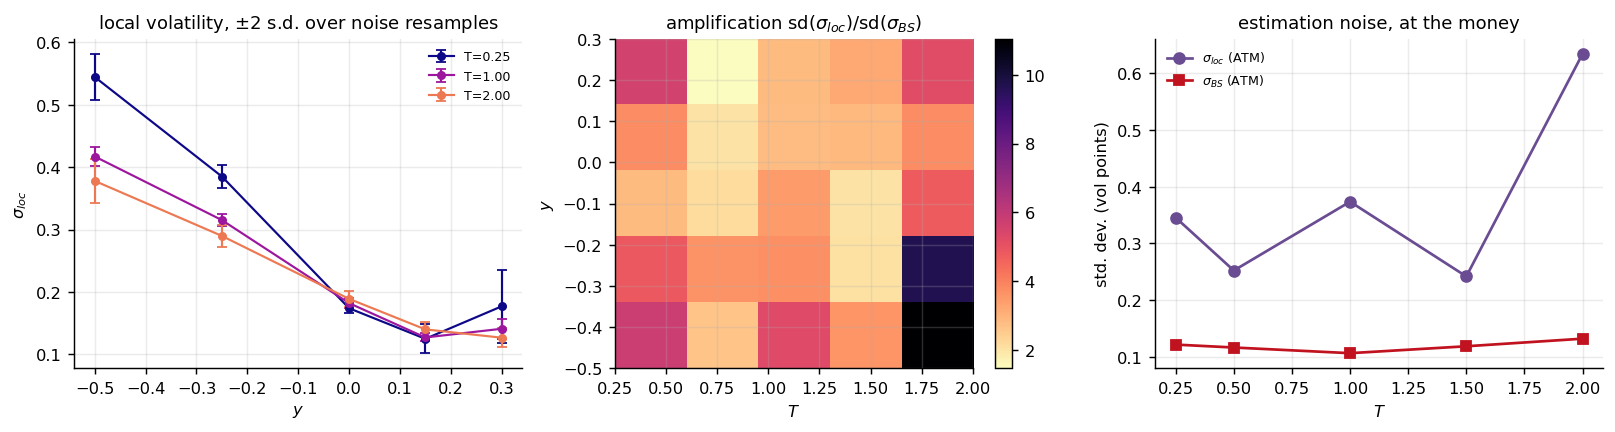

In [15]:
"""How much of the local-volatility surface is actually determined by the data?

We resample the microstructure noise (the exact prices are held fixed, only the
quoting error and the tick rounding are redrawn), re-run the *entire* pipeline,
and look at the induced dispersion of sigma_loc.  This is the honest error bar:
it is the part of the answer that comes from the estimator rather than from the
market.
"""
N_BOOT = 16
rng_b = np.random.default_rng(999)
y_probe = np.array([-0.5, -0.25, 0.0, 0.15, 0.30])
T_probe = np.array([0.25, 0.5, 1.0, 1.5, 2.0])
boot_lv = np.full((N_BOOT, len(y_probe), len(T_probe)), np.nan)
boot_iv = np.full((N_BOOT, len(y_probe), len(T_probe)), np.nan)

exact = quotes.price_exact.to_numpy()
vega0 = quotes.vega.to_numpy()
Kq, Tq, kq = quotes.K.to_numpy(), quotes["T"].to_numpy(), quotes["kind"].to_numpy()

for b in range(N_BOOT):
    noisy = exact + vega0 * rng_b.normal(0.0, IV_NOISE, size=exact.size)
    mid = np.maximum(np.round(noisy / TICK) * TICK, TICK)
    iv_b = np.array([implied_vol(float(mid[j]), S0, float(Kq[j]), float(Tq[j]), r, q, str(kq[j]))
                     for j in range(mid.size)])
    keep = np.isfinite(iv_b) & (mid >= 0.05)
    try:
        es_b = calibrate_essvi(np.log(Kq[keep] / (S0 * np.exp((r - q) * Tq[keep]))),
                               Tq[keep], iv_b[keep],
                               weights=vega0[keep], y_max=1.4, n_grid=241)
        Sb = TotalVarianceSurface(es_b.T_nodes,
                                  list(zip(es_b.theta_nodes, es_b.rho_nodes, es_b.p_nodes)))
        for i, yy in enumerate(y_probe):
            for j, tt in enumerate(T_probe):
                boot_lv[b, i, j] = float(local_vol_from_surface(Sb, yy, tt))
                boot_iv[b, i, j] = float(Sb.iv(yy, tt))
    except Exception as e:                                   # pragma: no cover
        print("  bootstrap replication failed:", e)

lv_mean, lv_sd = np.nanmean(boot_lv, axis=0), np.nanstd(boot_lv, axis=0)
iv_sd = np.nanstd(boot_iv, axis=0)
AMP = lv_sd / np.maximum(iv_sd, 1e-12)
print("Noise amplification: sd(sigma_loc) / sd(sigma_BS) at the probe points")
print(pd.DataFrame(AMP, index=[f"y={v:+.2f}" for v in y_probe],
                   columns=[f"T={t:.2f}" for t in T_probe])
      .to_string(float_format=lambda v: f"{v:6.2f}"))
print("\nsd(sigma_loc) in volatility points")
print(pd.DataFrame(lv_sd * 100, index=[f"y={v:+.2f}" for v in y_probe],
                   columns=[f"T={t:.2f}" for t in T_probe])
      .to_string(float_format=lambda v: f"{v:6.2f}"))

fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.4))
for j, tt in enumerate(T_probe[[0, 2, 4]]):
    jj = [0, 2, 4][j]
    yy = np.linspace(-0.7, 0.4, 120)
    band_lo, band_hi, ctr = [], [], []
    for i, yv in enumerate(y_probe):
        pass
    ax[0].errorbar(y_probe, lv_mean[:, jj], yerr=2 * lv_sd[:, jj], fmt="o-", ms=4, lw=1.2,
                   capsize=3, color=plt.cm.plasma(j / 3), label=f"T={tt:.2f}")
ax[0].set(xlabel="$y$", ylabel=r"$\sigma_{loc}$",
          title=r"local volatility, $\pm2$ s.d. over noise resamples")
ax[0].legend(fontsize=7)
im = ax[1].imshow(AMP, aspect="auto", origin="lower", cmap="magma_r",
                  extent=[T_probe[0], T_probe[-1], y_probe[0], y_probe[-1]])
plt.colorbar(im, ax=ax[1])
ax[1].set(xlabel="$T$", ylabel="$y$",
          title=r"amplification $\mathrm{sd}(\sigma_{loc})/\mathrm{sd}(\sigma_{BS})$")
ax[2].plot(T_probe, lv_sd[2] * 100, "o-", color=C_LV, label=r"$\sigma_{loc}$ (ATM)")
ax[2].plot(T_probe, iv_sd[2] * 100, "s-", color=C_FIT, label=r"$\sigma_{BS}$ (ATM)")
ax[2].set(xlabel="$T$", ylabel="std. dev. (vol points)",
          title="estimation noise, at the money")
ax[2].legend(fontsize=7)
fig.tight_layout(); fig.savefig(f"{FIG}/f11_robustness.png"); plt.show()


## 14. Conclusions

1. **Implied-volatility inversion is well posed** but badly conditioned in the wings, where vega
   vanishes exponentially. A one-cent tick can move a deep out-of-the-money implied volatility by
   several volatility points.
2. **Naive differentiation of quotes is hopeless.** The second difference has RMSE
   $\asymp ah^2+b/h^2$ with $b\propto\epsilon$; the best attainable accuracy scales only as
   $\epsilon^{1/2}$, and the optimal step is wider than the listed strike spacing. Applied
   directly to the quote ladder, Dupire's formula returns negative local variances on a
   substantial fraction of nodes.
3. **Regularisation by an arbitrage-free parameterisation is the cure, and it denoises.** The
   fitted surface is *closer to the truth than the data it was fitted to*.
4. **Arbitrage-freeness is not cosmetic**: Durrleman's function is literally the denominator of
   Dupire's formula. Butterfly arbitrage makes the local variance blow up or turn negative;
   calendar arbitrage makes the numerator negative.
5. **The extraction is accurate where there are quotes, and meaningless where there are not.**
   Inside the quoted band the recovered surface matches ground truth to a fraction of a
   volatility point; outside it, the error grows by an order of magnitude.
6. **Local volatility reprices every vanilla and mis-prices path-dependent payoffs.** Barrier
   and cliquet prices under local volatility and under the true Heston dynamics differ by
   several percent although the two models agree on every European option — the exact content of
   Gyöngy's theorem.

### References

- Albrecher, H., Mayer, P., Schoutens, W., Tistaert, J. (2007). The little Heston trap. *Wilmott*, 83--92.
- Andersen, L. (2008). Simple and efficient simulation of the Heston stochastic volatility model. *Journal of Computational Finance* 11(3), 1--42.
- Breeden, D., Litzenberger, R. (1978). Prices of state-contingent claims implicit in option prices. *Journal of Business* 51(4), 621--651.
- Brenner, M., Subrahmanyam, M. (1988). A simple formula to compute the implied standard deviation. *Financial Analysts Journal* 44(5), 80--83.
- Broadie, M., Glasserman, P., Kou, S. (1997). A continuity correction for discrete barrier options. *Mathematical Finance* 7(4), 325--349.
- Dupire, B. (1994). Pricing with a smile. *Risk* 7(1), 18--20.
- Durrleman, V. (2010). From implied to spot volatilities. *Finance and Stochastics* 14(2), 157--177.
- Fang, F., Oosterlee, C. W. (2008). A novel pricing method for European options based on Fourier-cosine series expansions. *SIAM J. Sci. Comput.* 31(2), 826--848.
- Fengler, M. (2009). Arbitrage-free smoothing of the implied volatility surface. *Quantitative Finance* 9(4), 417--428.
- Fritsch, F., Carlson, R. (1980). Monotone piecewise cubic interpolation. *SIAM J. Numer. Anal.* 17(2), 238--246.
- Gatheral, J. (2004). A parsimonious arbitrage-free implied volatility parameterization. Global Derivatives, Madrid.
- Gatheral, J. (2006). *The Volatility Surface: A Practitioner's Guide*. Wiley.
- Gatheral, J., Jacquier, A. (2014). Arbitrage-free SVI volatility surfaces. *Quantitative Finance* 14(1), 59--71.
- Glasserman, P. (2004). *Monte Carlo Methods in Financial Engineering*. Springer.
- Gyöngy, I. (1986). Mimicking the one-dimensional marginal distributions of processes having an Itô differential. *Probab. Theory Related Fields* 71(4), 501--516.
- Hendriks, S., Martini, C. (2019). The extended SSVI volatility surface. *Journal of Computational Finance* 22(5), 25--39.
- Heston, S. (1993). A closed-form solution for options with stochastic volatility. *Review of Financial Studies* 6(2), 327--343.
- Kloeden, P., Platen, E. (1992). *Numerical Solution of Stochastic Differential Equations*. Springer.
- Lee, R. (2004). The moment formula for implied volatility at extreme strikes. *Mathematical Finance* 14(3), 469--480.
- Roper, M. (2010). Arbitrage-free implied volatility surfaces. Preprint, University of Sydney.
- Tikhonov, A., Arsenin, V. (1977). *Solutions of Ill-Posed Problems*. Winston & Sons.
